# Assignment 2: Network Generation and Validation 
## Task 
This worksheet will look into the undertaking of generating a Randomised Erdős–Rényi network of sizes ranging from 20-50k and attempt to rewire as many nodes as possible to form into cliques that are close to a specified target (in this case 5). All the while minimuising the impact of the overall degree distribution. 

## Task Observations and Assumptions
Given the task, there have been a few core things to note during the running of this tasks: 
1. Degree Distribution is unlikely to stay the same during the rewiring process. As such, there is an allowance for a +/- variance of 10% from the original value before stopping the rewiring process. 
2. There is no minimum quota on how many cliques should be rewired to meet the target or be in close proximity to it. The objective is to try do as many as possible. This could mean the number of cliques formed can vary in size and at times may be small.  
3. To improve the efficiency of the rewiring process, we ignore cliques that are already close to the target value. The same is done during rewiring using a rewiring cache. 
4. This code is adjustable and as such there have been some measures put in place to stop certain failing scenarios occuring (like asking for more cliques than you have nodes)
5. The code is broken up to be more modular and to enforce clean coding practices (DRY, Low Coupling, High Cohesion, and no more than 30 lines of code per method or function).  
6. It was noted that some issues were occuring when runing multiple simlations in the one go. As such, garbage collection is carried out after every simulation to clear down as much unused memory use as possible. 
7. There are only two other files outside of this notebook to be aware of, these are the NetworkGenerator.py and the Rewirer.py. If these are not present in the provided folder then this notebook will not run.
8. The networks generated are random, as is degree distribution. It is unlikely that you will encounter two networks with the same values in a previous run, if you do, you may wish to repeat the notebook. 
9. To prevent the rewiring process taking an excessively long time, two conditions were created. The first is Max Consequtive Failures, which stops the rewiring process if something within the rewiring process does not comply with the allowed rewiring rules (no missing edges, average degree now crosses allowed threashold, rewiring process attempted to use a node already rewired)Max Attempts, which prevents the network from trying too many different combinations of rewiring.


## Step 1 Import required packages
If these are not installed on your machine the below command should be able to install them for you. 


In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\RRHMc\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
%matplotlib inline
import numpy as np, matplotlib.pyplot as plt
import random as rng
import gc
from NetworkGenerator import NetworkGenerator
from Rewirer import Rewirer
from ReportingModule import ReportingModule

## Step 2: Network reporting implementation

### Step 2.1: Network Reporting Class 
Initialising this class enables the core part of the reporting process to be carried out

In [3]:
reporter = ReportingModule()

In [4]:
def _log_network_state(label: str, ntwk) -> None:
    """
    Print a labelled snapshot of the network through ReportingModule.

    @param label: Descriptive heading for this snapshot.
    @param ntwk: The network to log.
    """
    reporter.log_network_state(label, ntwk)


def _cleanup_simulation_state():
    """
    Release matplotlib state and trigger garbage collection between runs.

    Closing figures here frees backend resources after each iteration without
    removing the visualisations already rendered in the notebook output.
    """
    plt.close("all")
    gc.collect()

### Step 2.2: Implement Network validation code
The code below will do our final check that the ER network that has been rewired is within our allowed percentage range for changes to Degree Distribution 

In [5]:
def validate_er_network(ntwk, original_degree_sequence):
    """
    Validate that the rewired network's mean degree is within +/- 10% of the
    original ER graph's mean degree.

    @param ntwk: The rewired network to validate.
    @type  ntwk: nx.Graph
    @param original_degree_sequence: Degree sequence of the pre-rewiring graph.
    @type  original_degree_sequence: list[int]
    @return: True if the degree distribution is within tolerance.
    @rtype:  bool
    """
    original_avg_degree = np.mean(original_degree_sequence)
    current_avg_degree = reporter.get_avg_degree_dist(ntwk)

    if original_avg_degree == 0:
        return current_avg_degree == 0

    return (
        abs(current_avg_degree - original_avg_degree) / original_avg_degree <= 0.10
    )

## Step 3 Run a single Trial Simulation
**Note:** The code below contains the core Network Generation, Rewiring, and Reporting process. 
The output can be broken down into two core parts - the state before rewiring, and the state afterwards. The former, includes details of the current degree distribution in both visual and textual form, and the count of cliques within the network. The latter also has these in the updated state and extends this to include metrics about the rewiring process, but also the metrics required to complete the rewiring process. 

Before moving to do multiple simuilations of this process, lets first check the output of a single runthrough. 

ER network created
Total nodes: 20000
Total edges: 140658
Average degree: 14.0658


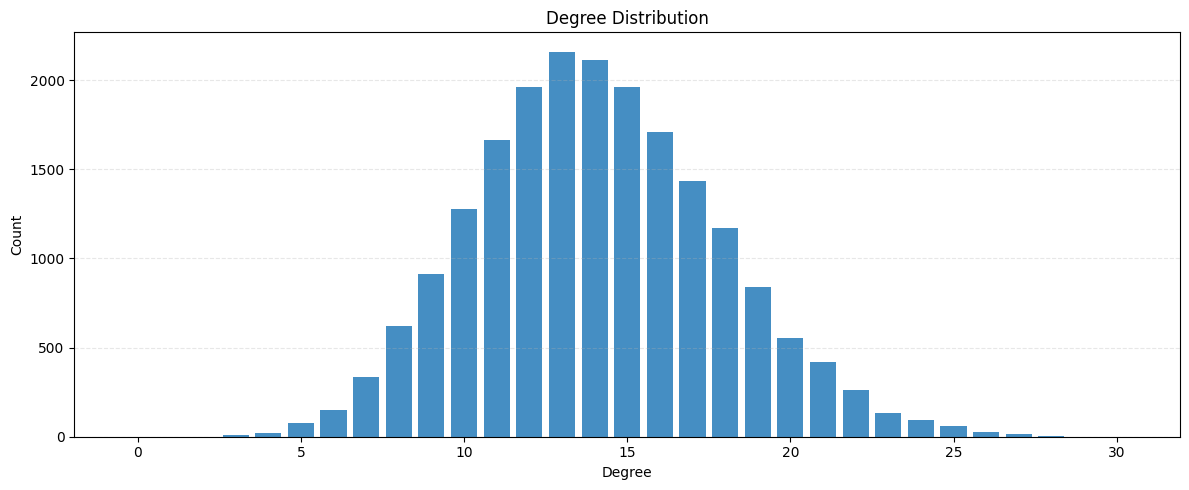

Clique size distribution (raw counts):
  Size 2: 139250 clique(s)
  Size 3: 472 clique(s)
Clique summary: total maximal cliques=139722, dominant size=2
Clique sizes present: 2, 3


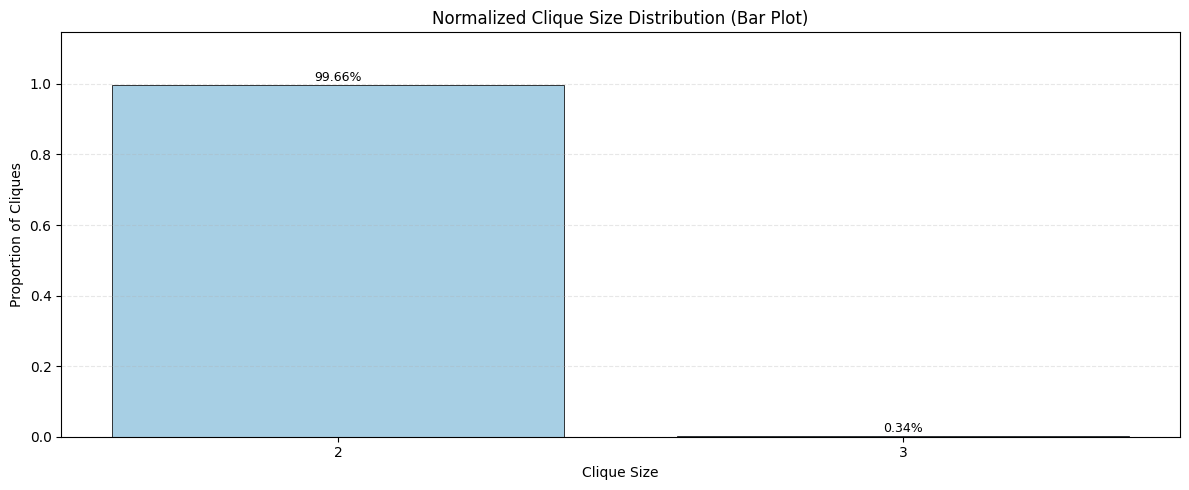

Rewiring stats:
  allowed clique sizes : [5, 4, 6, 3, 7]
  attempts            : 201407
  successful rewires  : 1407
  cache hits          : 0
  already-clique skips: 0
  tolerance rejections: 200000
  avg degree          : 14.0658 -> 15.4723
  stop reason         : max_consecutive_failures
ER network rewired (valid)
Total nodes: 20000
Total edges: 154723
Average degree: 15.4723


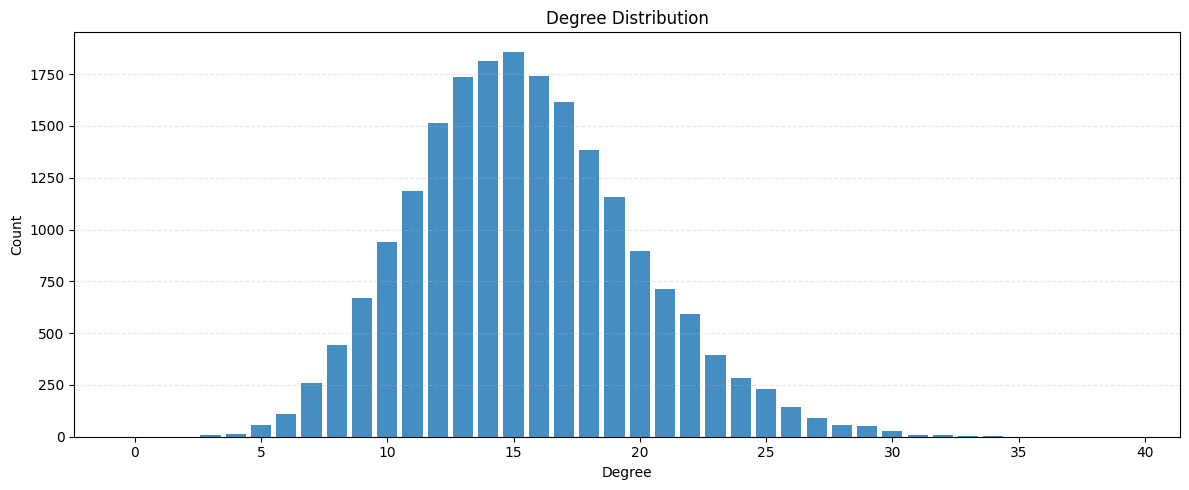

Clique size distribution (raw counts):
  Size 2: 138966 clique(s)
  Size 3: 620 clique(s)
  Size 5: 1407 clique(s)
Clique summary: total maximal cliques=140993, dominant size=2
Clique sizes present: 2, 3, 5


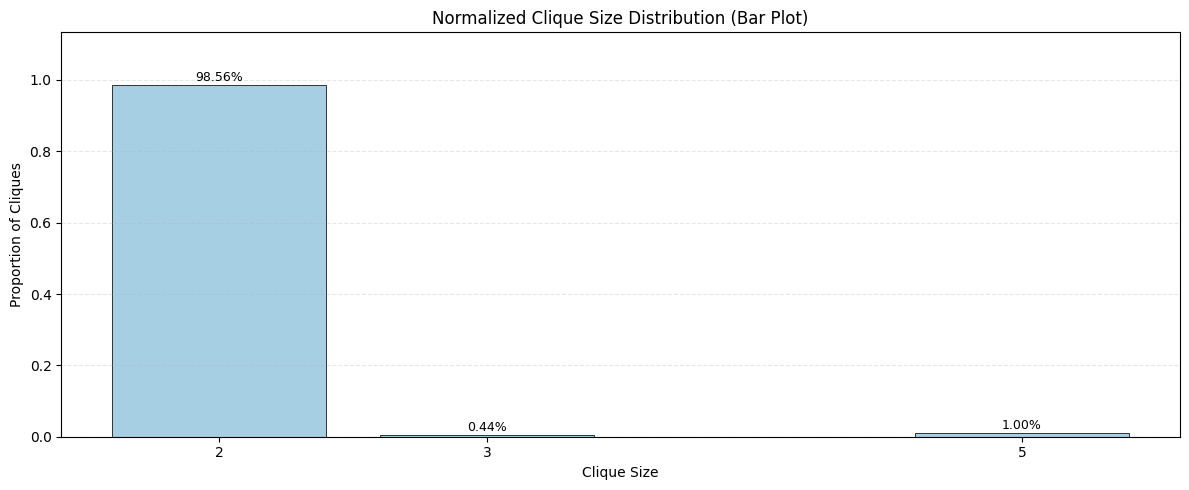

(np.True_,
 {'node_count': 20000,
  'target_clique_size': 5,
  'allowed_clique_sizes': [5, 4, 6, 3, 7],
  'degree_tolerance': 0.1,
  'original_avg_degree': 14.0658,
  'final_avg_degree': 15.4723,
  'total_attempts': 201407,
  'successful_rewirings': 1407,
  'cache_hits': 0,
  'already_clique_groups': 0,
  'tolerance_rejections': 200000,
  'termination_reason': 'max_consecutive_failures'})

In [6]:
def run_single_network_simulation(
    num_nodes,
    kmean,
    clique_size,
    visualise=False,
    return_network=True,
    cleanup_after_run=False,
    print_summary=True,
):
    """
    Generate a connected ER graph, rewire it with cliques, and validate.

    @param num_nodes: Number of nodes in the generated graph.
    @param kmean: Target mean degree for the ER graph.
    @param clique_size: Target clique size passed to the rewirer.
    @param visualise: Print stats and plot distributions when True.
    @param return_network: Keep and return the rewired graph when True.
    @param cleanup_after_run: Force cleanup before returning when True.
    @param print_summary: Print compact run stats when True.
    @return: Tuple containing validation result, optional network, and run stats.
    """
    generator = None
    ntwk = None
    original_degree_sequence = None
    rewirer = None
    run_stats = None
    try:
        generator = NetworkGenerator(num_nodes, kmean)
        ntwk = generator.generate_erdos_renyi_graph(require_connected=True)
        original_degree_sequence = sorted([d for _, d in ntwk.degree()])
        if visualise:
            _log_network_state("ER network created", ntwk)
        rewirer = Rewirer(ntwk)
        ntwk = rewirer.rewire_network_cliques(clique_size, print_stats=visualise)
        model_valid = validate_er_network(ntwk, original_degree_sequence)
        run_stats = rewirer.get_last_run_stats()
        if visualise:
            _log_network_state(
                f"ER network rewired ({'valid' if model_valid else 'invalid'})", ntwk
            )
        elif print_summary and run_stats is not None:
            print(
                "Run summary:",
                f"valid={model_valid}, attempts={run_stats['total_attempts']}, ",
                f"rewires={run_stats['successful_rewirings']}, ",
                f"termination={run_stats['termination_reason']}",
                sep=""
            )

        if cleanup_after_run and not return_network:
            ntwk = None
            _cleanup_simulation_state()

        if return_network:
            return model_valid, ntwk, run_stats
        return model_valid, run_stats
    finally:
        generator = None
        original_degree_sequence = None
        rewirer = None
        if cleanup_after_run and not return_network:
            ntwk = None
            run_stats = None
            gc.collect()


run_single_network_simulation(20000, rng.randint(5, 20), 5, visualise=True)


### How to know that the work done is valid? 
Given the size and nature of the process carried out, it would be quite difficult to visually demonstrate the changed state between the original and rewired network. When looking at the ER network's degree distribution, in histograph form, the behiour of the total for degree distribution counts should follow the form of a bell curve. Should the rewired network not have a similar behaviour then we can deem the rewiring process unsuccessful. Another way to check that the rewiring process has been successful is the average degree distribution. The average value of the degree distribution should be retained within 10% of the original value. To save time on the calculation, a validation check will indicate whether the network is valid or not for this and can be seen in the above log after the simulation has been run. Lastly, the bar graph indicating clique count percentages should demonstrate a change in clique totals to see an increase in the direction of the target value. At times, results may see a slim change compared to the original network. So as long as there is evidence that rewiring has achieved some clique formations close to the target value without excessively chaning the degree distributions, then the process is deemed successful 

### Output from simulation 
With the original rewired diagram, typically returning cliques of majority size 2 and a small number of size 3. We would look to increase as many of those cliques at size two to be moved to within the numbers surrounding 5 as possible. Rewiring may take some time depending on the complexity of the network, but previous runs indicated that between 1-2 mins on a machine with adequate resources to process is the average. 
After Rewiring, we typically see a specific increase in the number of cliques which are of the target value and a slight increase in the surrounding values as well. As an interesting observation, the rewiring process is able to form cliques of size 5 and 3, but has difficulty at times form cliques of size 4. Another observation is that the network still retains a majority of cliques of size 2. It is likely that this is because impacting this siginficantly would change the average degree distribution beyond acceptable limits, and so we will likely not see a drastic change in the number of cliques of size 2. From looking as well at the output from the rewiring process, the reason for rewiring terminating is due to the limit on the number of failures being reached, suggesting that the process could not proceed any further without breaking one of the assumptions or critiera that was mentioned in the Assumptions and Notes section. 
### Conclusion
With this in mind, this single experiment should have demonstrated compliance with the requirements of the task and returned a valid rewired network with clique totals closer to the target value. 

## Step 4: Run Multiple Simulations

Now that it is possible to show that a random ER network can be rewired, lets try a number of different random networks with a slightly larger node range than what was used in the initial run. 

### Step 4.1 Run Multiple simulations within a 20-30k Node range

Running simulation 1/5
Simulation parameters: nodes=27543, kmean=34, clique_size=5
ER network created
Total nodes: 27543
Total edges: 468623
Average degree: 34.02846458265258


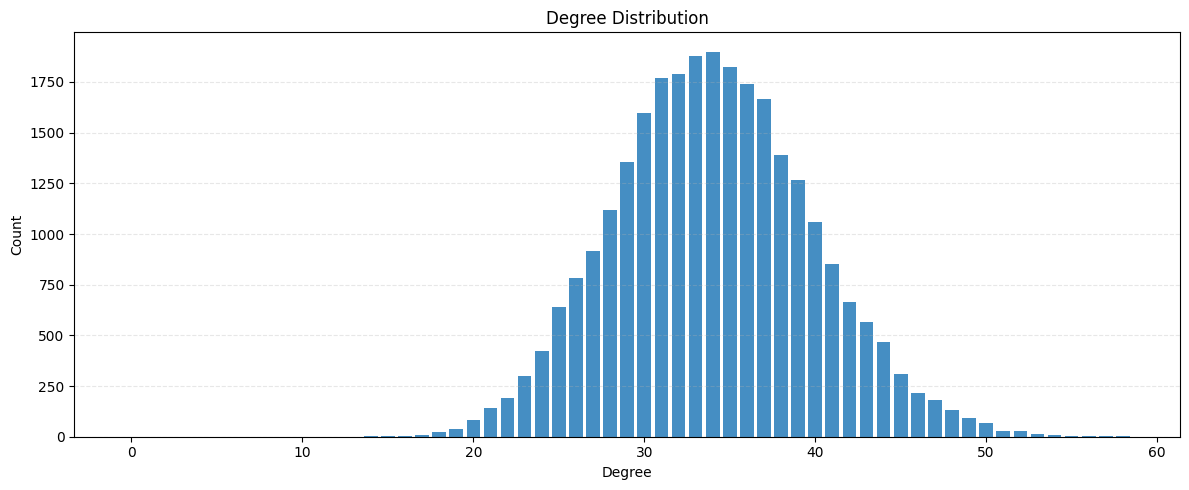

Clique size distribution (raw counts):
  Size 2: 448991 clique(s)
  Size 3: 6695 clique(s)
Clique summary: total maximal cliques=455686, dominant size=2
Clique sizes present: 2, 3


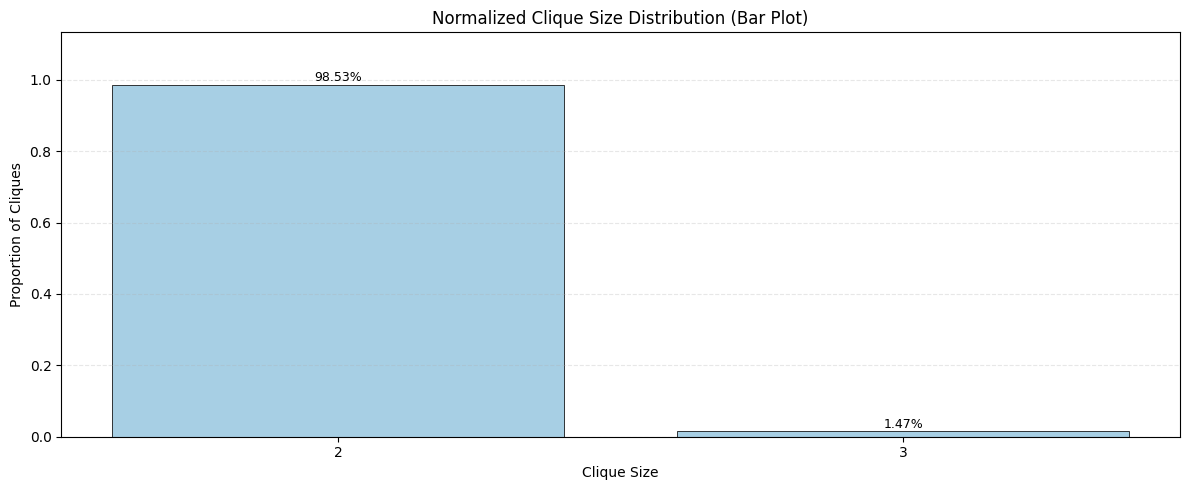

Rewiring stats:
  allowed clique sizes : [5, 4, 6, 3, 7]
  attempts            : 280124
  successful rewires  : 4693
  cache hits          : 0
  already-clique skips: 0
  tolerance rejections: 275431
  avg degree          : 34.0285 -> 37.4313
  stop reason         : max_consecutive_failures
ER network rewired (valid)
Total nodes: 27543
Total edges: 515485
Average degree: 37.43128925679846


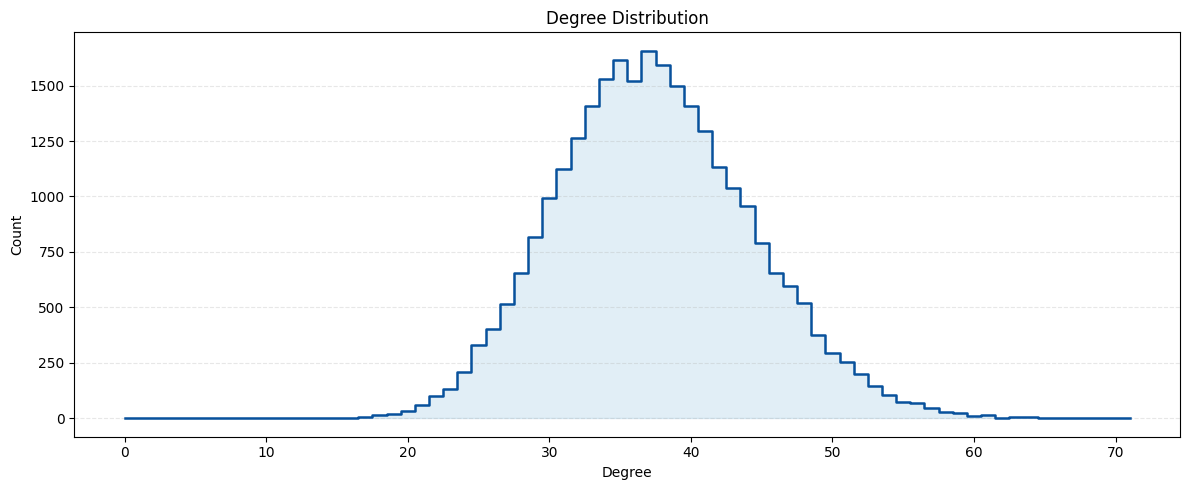

Clique size distribution (raw counts):
  Size 2: 444800 clique(s)
  Size 3: 8962 clique(s)
  Size 4: 5 clique(s)
  Size 5: 4692 clique(s)
Clique summary: total maximal cliques=458459, dominant size=2
Clique sizes present: 2, 3, 4, 5


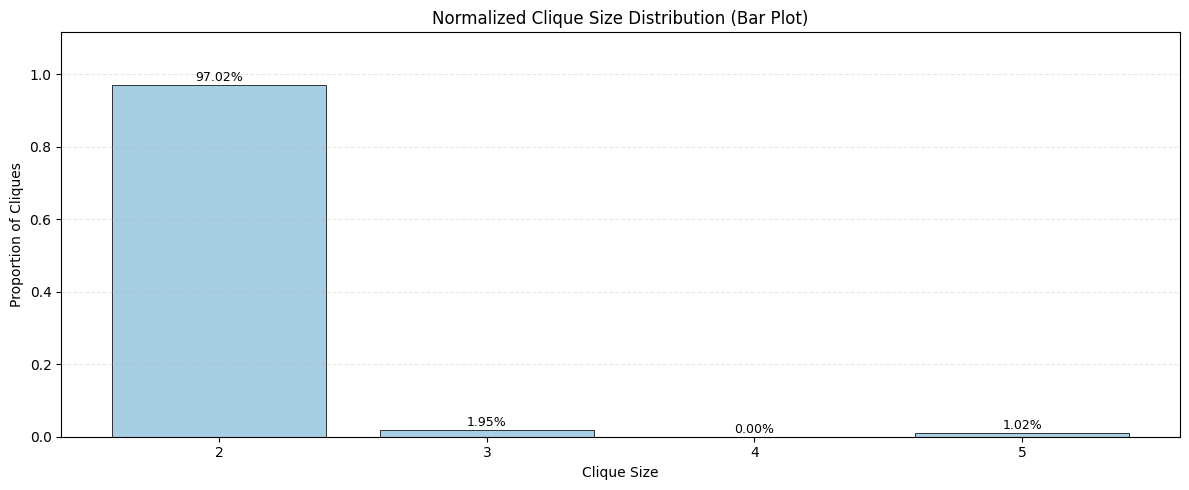

Simulation 1 valid: True
Batch summary:  rewires=4693,  attempts=280124,  termination=max_consecutive_failures
Simulation 1 complete - memory cleared.

Running simulation 2/5
Simulation parameters: nodes=21967, kmean=20, clique_size=5
ER network created
Total nodes: 21967
Total edges: 219346
Average degree: 19.97050120635499


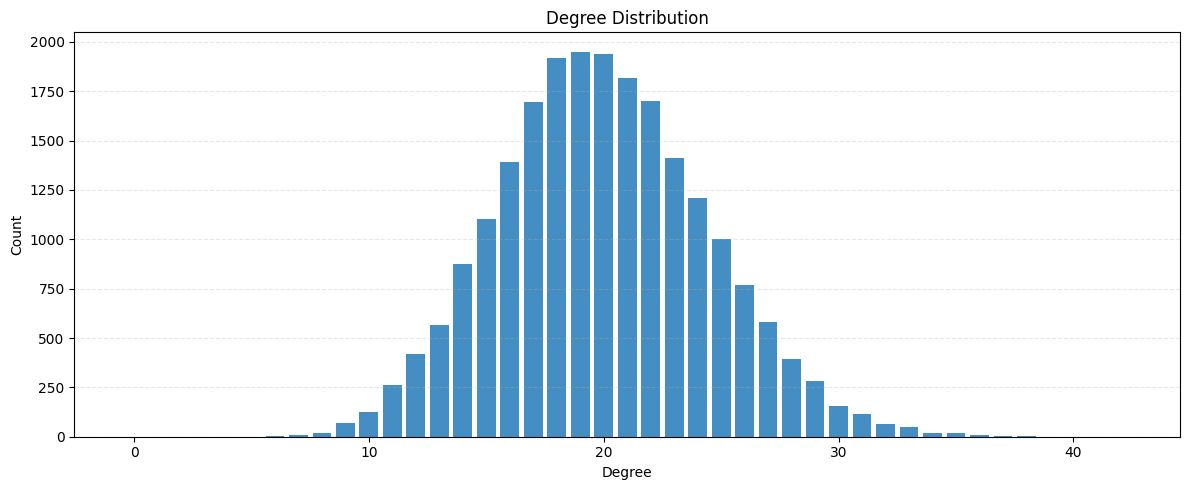

Clique size distribution (raw counts):
  Size 2: 215336 clique(s)
  Size 3: 1347 clique(s)
Clique summary: total maximal cliques=216683, dominant size=2
Clique sizes present: 2, 3


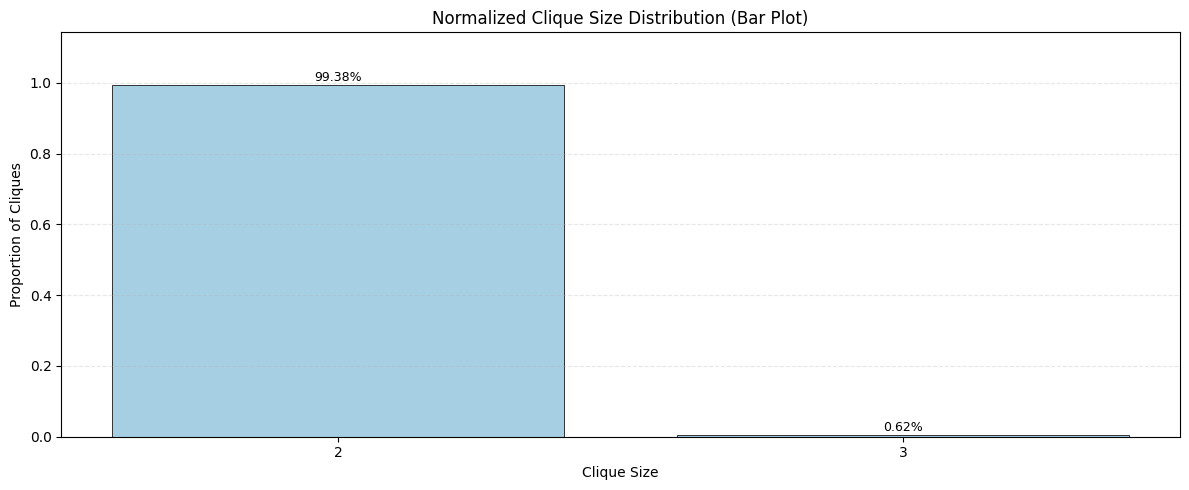

Rewiring stats:
  allowed clique sizes : [5, 4, 6, 3, 7]
  attempts            : 221869
  successful rewires  : 2196
  cache hits          : 0
  already-clique skips: 0
  tolerance rejections: 219673
  avg degree          : 19.9705 -> 21.9675
  stop reason         : max_consecutive_failures
ER network rewired (valid)
Total nodes: 21967
Total edges: 241280
Average degree: 21.967496699594847


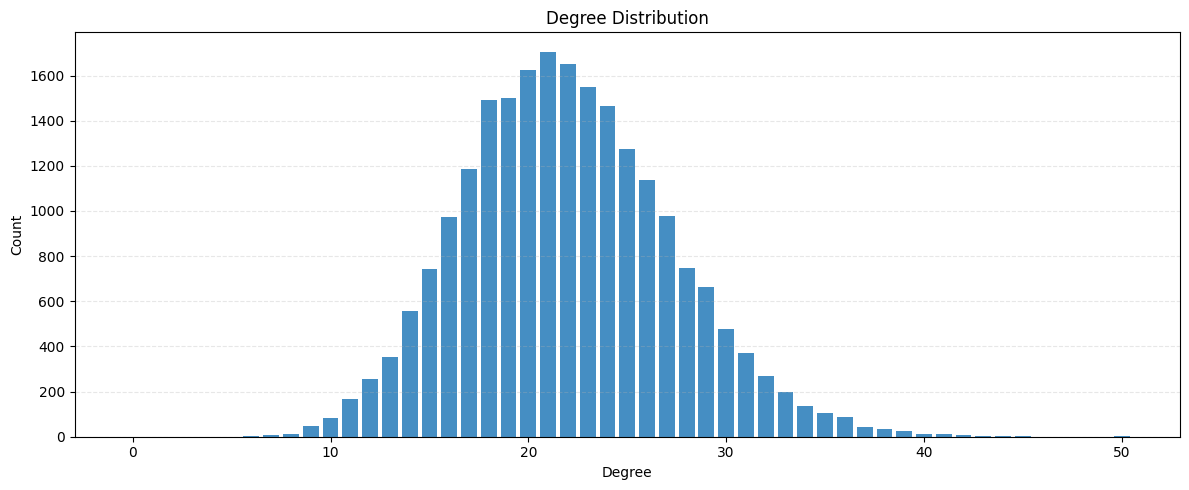

Clique size distribution (raw counts):
  Size 2: 214486 clique(s)
  Size 3: 1795 clique(s)
  Size 4: 1 clique(s)
  Size 5: 2195 clique(s)
Clique summary: total maximal cliques=218477, dominant size=2
Clique sizes present: 2, 3, 4, 5


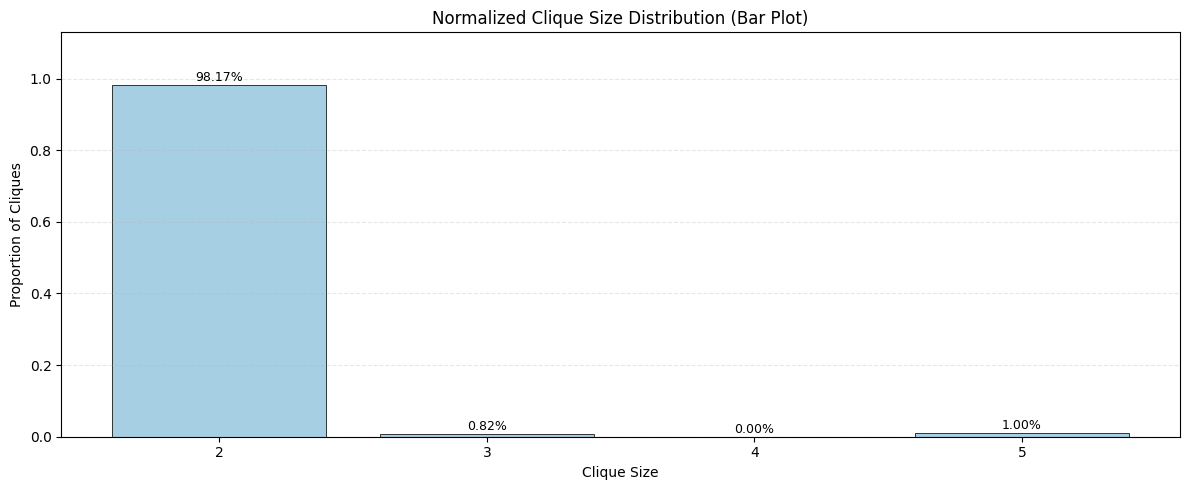

Simulation 2 valid: True
Batch summary:  rewires=2196,  attempts=221869,  termination=max_consecutive_failures
Simulation 2 complete - memory cleared.

Running simulation 3/5
Simulation parameters: nodes=24228, kmean=46, clique_size=5
ER network created
Total nodes: 24228
Total edges: 557485
Average degree: 46.019894337130594


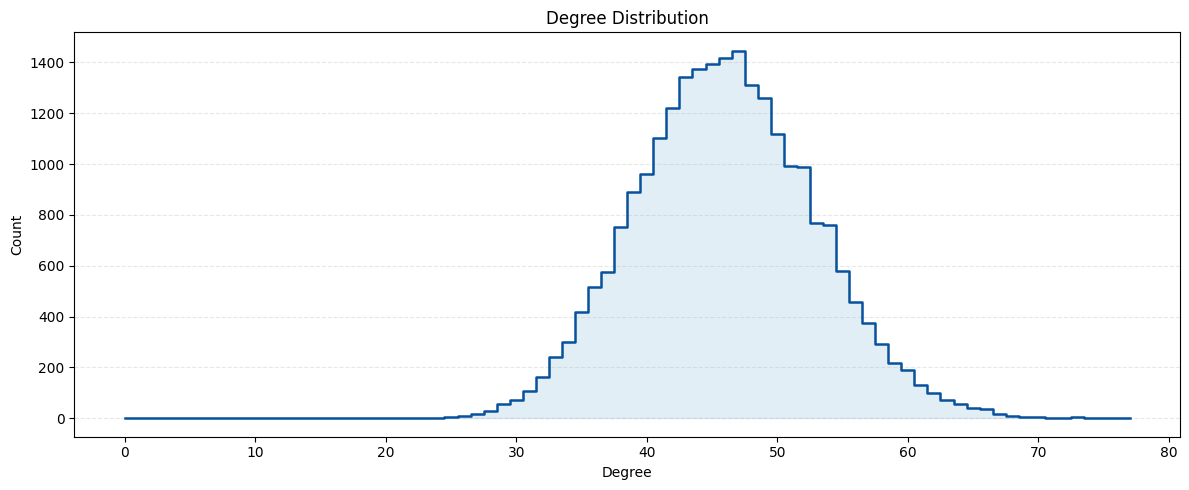

Clique size distribution (raw counts):
  Size 2: 510914 clique(s)
  Size 3: 16199 clique(s)
  Size 4: 1 clique(s)
Clique summary: total maximal cliques=527114, dominant size=2
Clique sizes present: 2, 3, 4


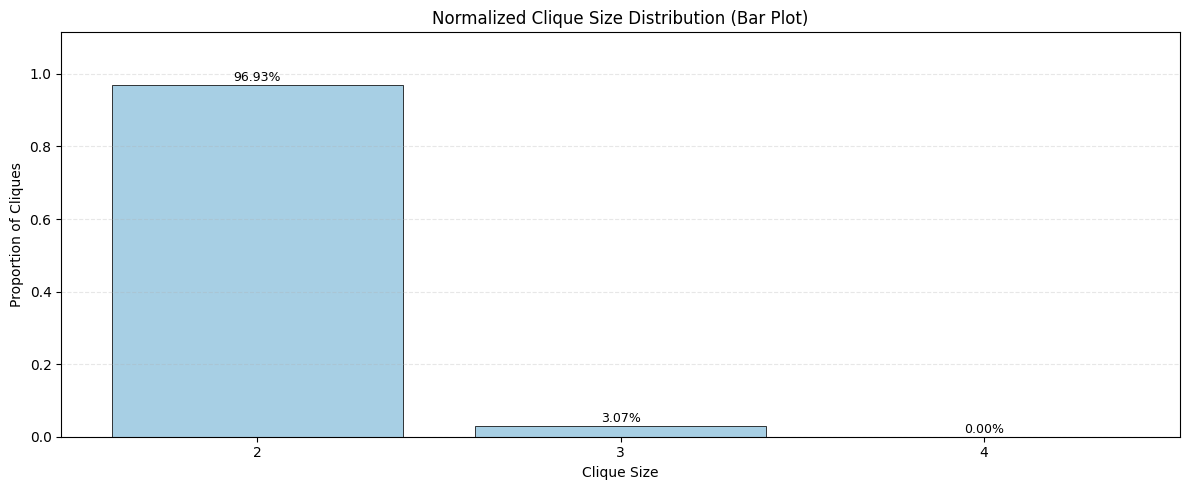

Rewiring stats:
  allowed clique sizes : [5, 4, 6, 3, 7]
  attempts            : 247866
  successful rewires  : 5586
  cache hits          : 0
  already-clique skips: 0
  tolerance rejections: 242280
  avg degree          : 46.0199 -> 50.6218
  stop reason         : max_consecutive_failures
ER network rewired (valid)
Total nodes: 24228
Total edges: 613233
Average degree: 50.62184249628529


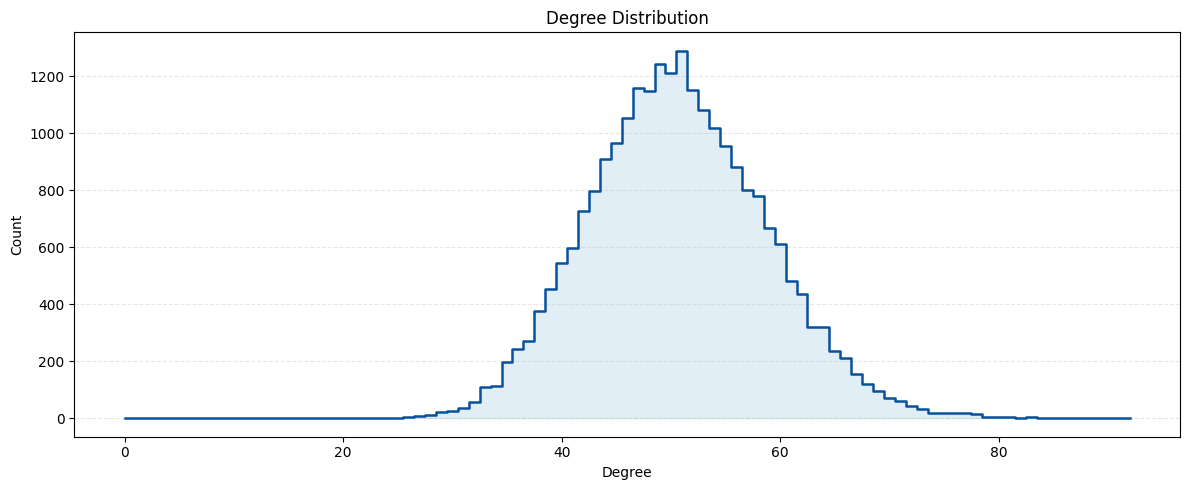

Clique size distribution (raw counts):
  Size 2: 501436 clique(s)
  Size 3: 21601 clique(s)
  Size 4: 11 clique(s)
  Size 5: 5586 clique(s)
Clique summary: total maximal cliques=528634, dominant size=2
Clique sizes present: 2, 3, 4, 5


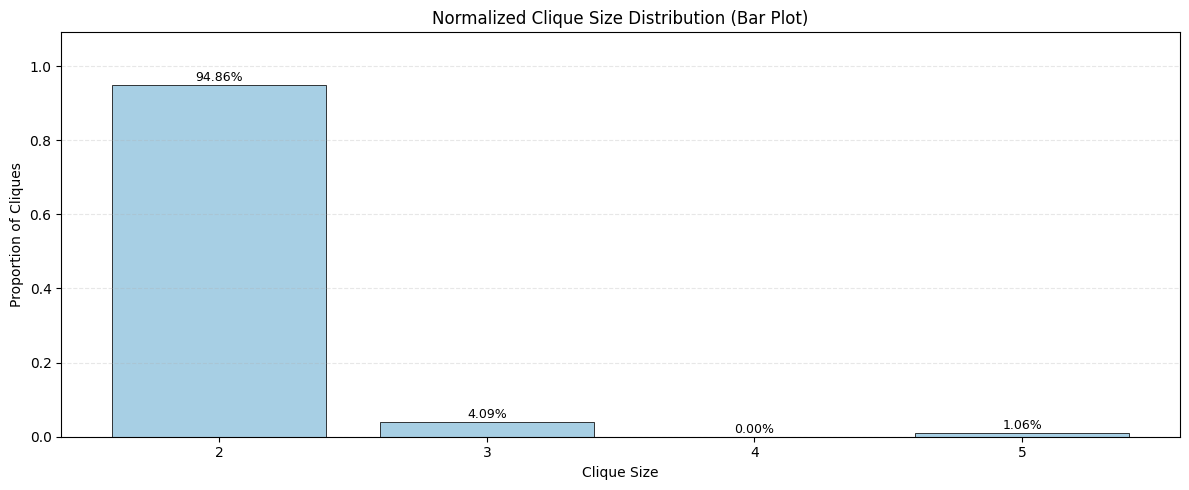

Simulation 3 valid: True
Batch summary:  rewires=5586,  attempts=247866,  termination=max_consecutive_failures
Simulation 3 complete - memory cleared.

Running simulation 4/5
Simulation parameters: nodes=26184, kmean=39, clique_size=5
ER network created
Total nodes: 26184
Total edges: 511114
Average degree: 39.04017720745493


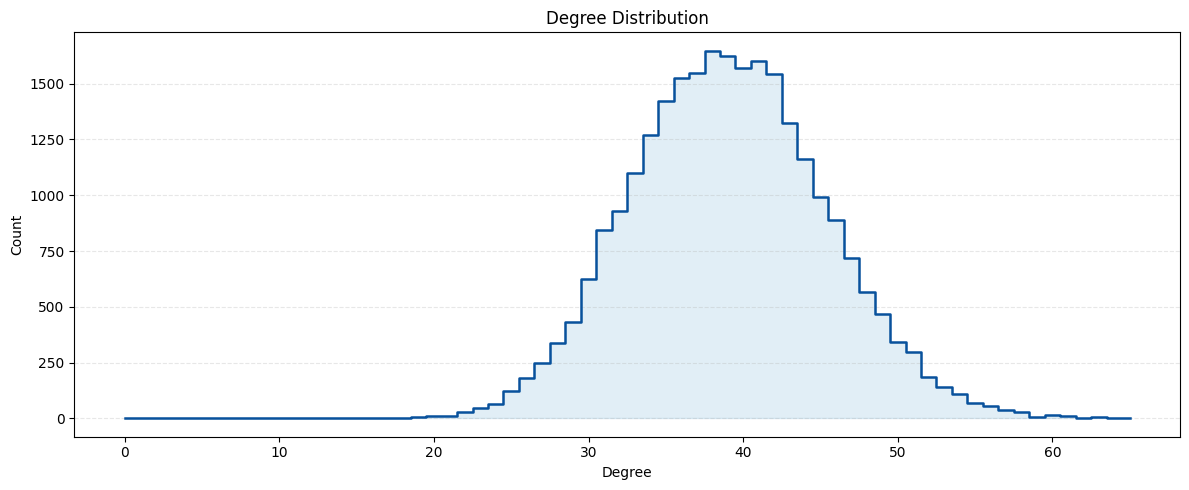

Clique size distribution (raw counts):
  Size 2: 481967 clique(s)
  Size 3: 9998 clique(s)
Clique summary: total maximal cliques=491965, dominant size=2
Clique sizes present: 2, 3


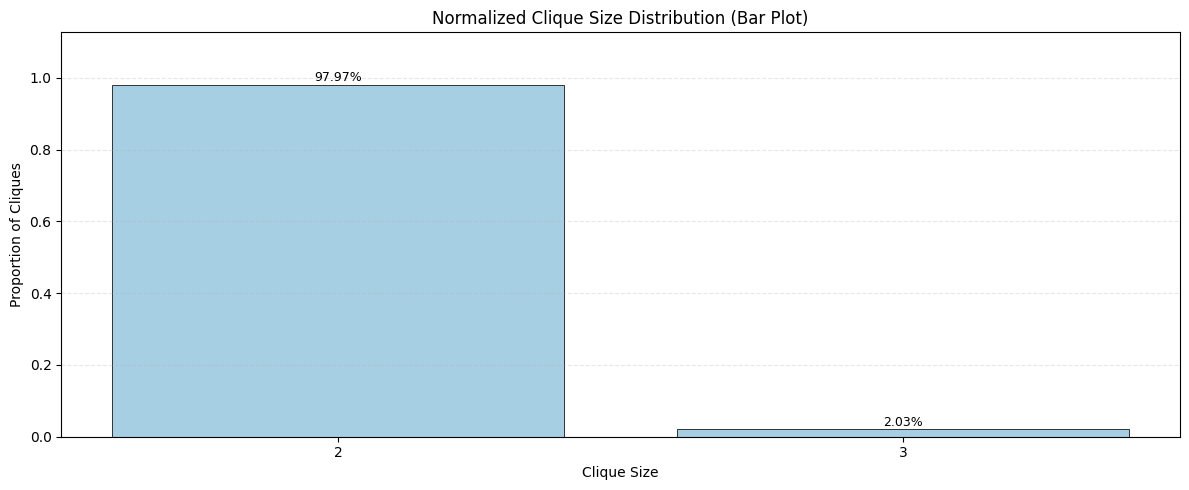

Rewiring stats:
  allowed clique sizes : [5, 4, 6, 3, 7]
  attempts            : 266965
  successful rewires  : 5122
  cache hits          : 0
  already-clique skips: 0
  tolerance rejections: 261843
  avg degree          : 39.0402 -> 42.9442
  stop reason         : max_consecutive_failures
ER network rewired (valid)
Total nodes: 26184
Total edges: 562225
Average degree: 42.94416437519096


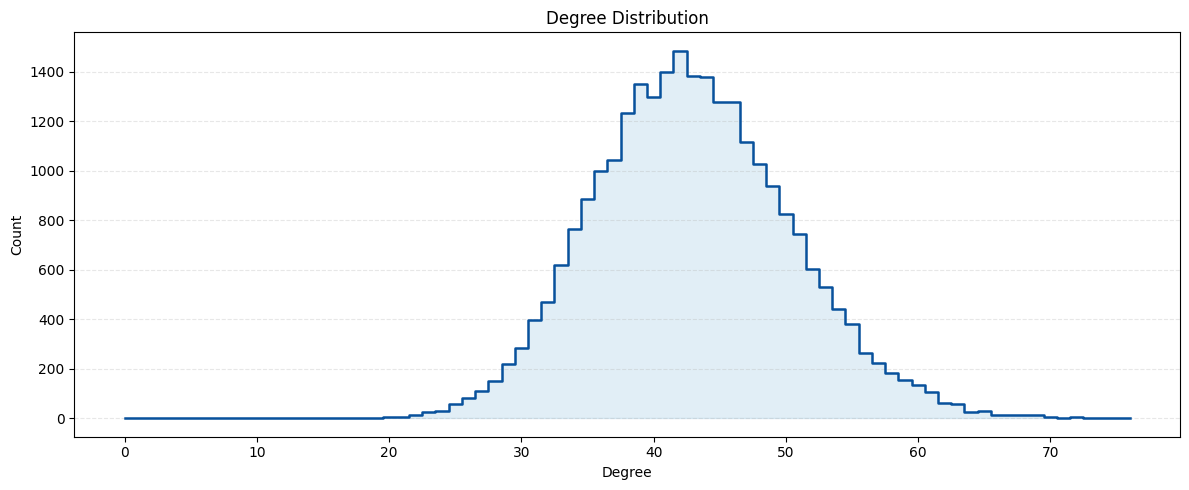

Clique size distribution (raw counts):
  Size 2: 476099 clique(s)
  Size 3: 13231 clique(s)
  Size 4: 9 clique(s)
  Size 5: 5121 clique(s)
Clique summary: total maximal cliques=494460, dominant size=2
Clique sizes present: 2, 3, 4, 5


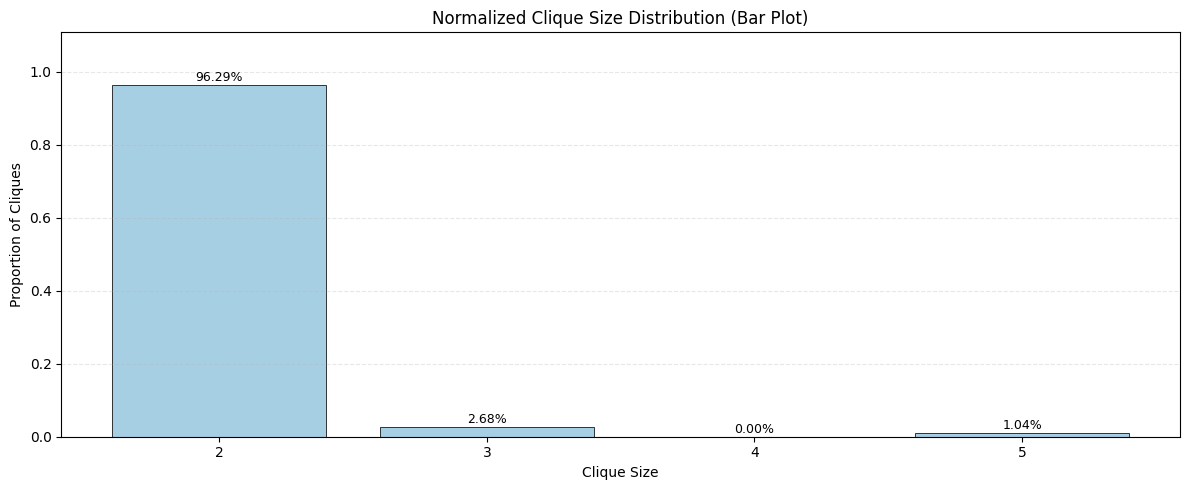

Simulation 4 valid: True
Batch summary:  rewires=5122,  attempts=266965,  termination=max_consecutive_failures
Simulation 4 complete - memory cleared.

Running simulation 5/5
Simulation parameters: nodes=26565, kmean=23, clique_size=5
ER network created
Total nodes: 26565
Total edges: 305279
Average degree: 22.983549783549783


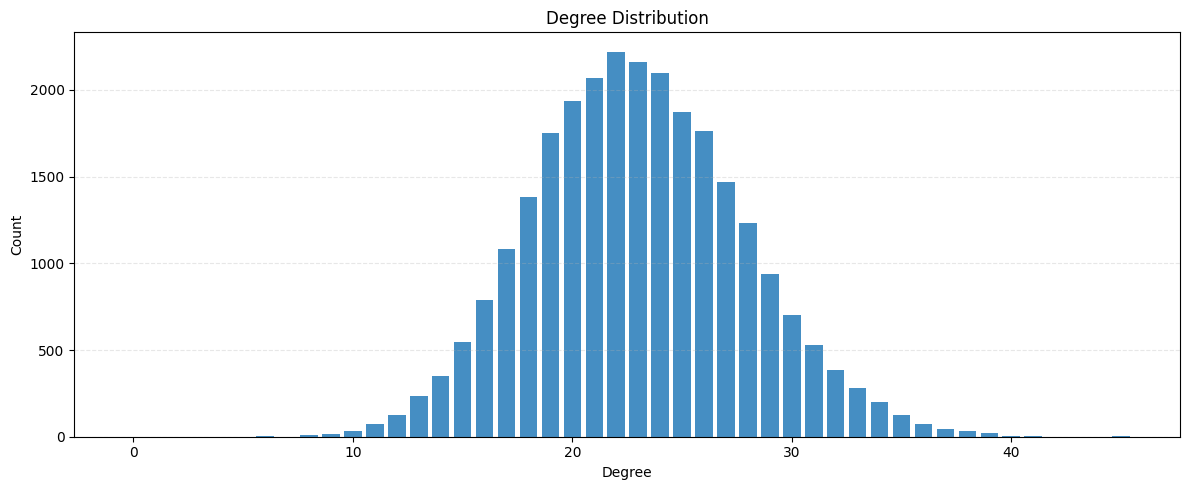

Clique size distribution (raw counts):
  Size 2: 299369 clique(s)
  Size 3: 1990 clique(s)
Clique summary: total maximal cliques=301359, dominant size=2
Clique sizes present: 2, 3


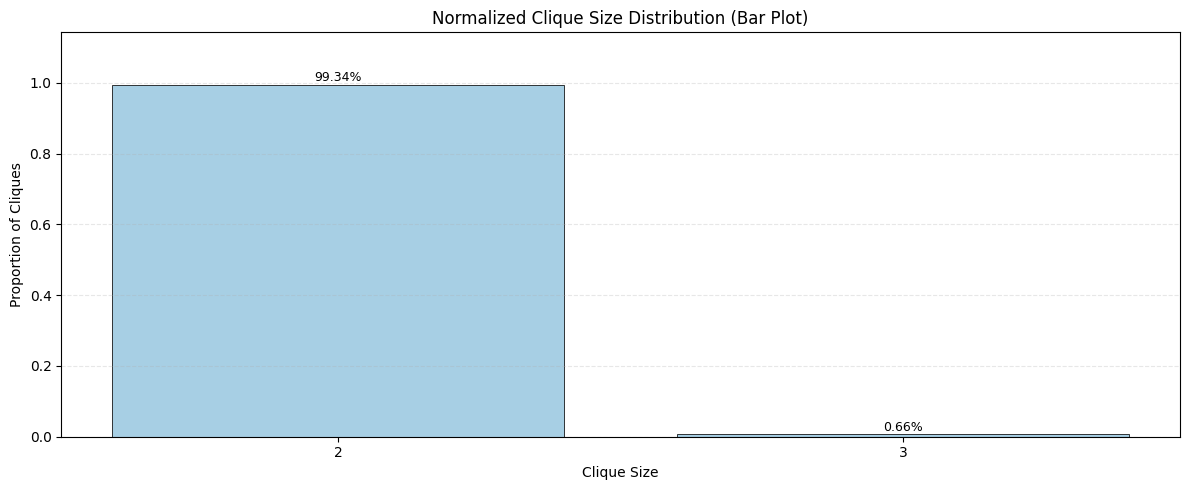

Rewiring stats:
  allowed clique sizes : [5, 4, 6, 3, 7]
  attempts            : 268709
  successful rewires  : 3056
  cache hits          : 0
  already-clique skips: 0
  tolerance rejections: 265653
  avg degree          : 22.9835 -> 25.2818
  stop reason         : max_consecutive_failures
ER network rewired (valid)
Total nodes: 26565
Total edges: 335806
Average degree: 25.281837003576133


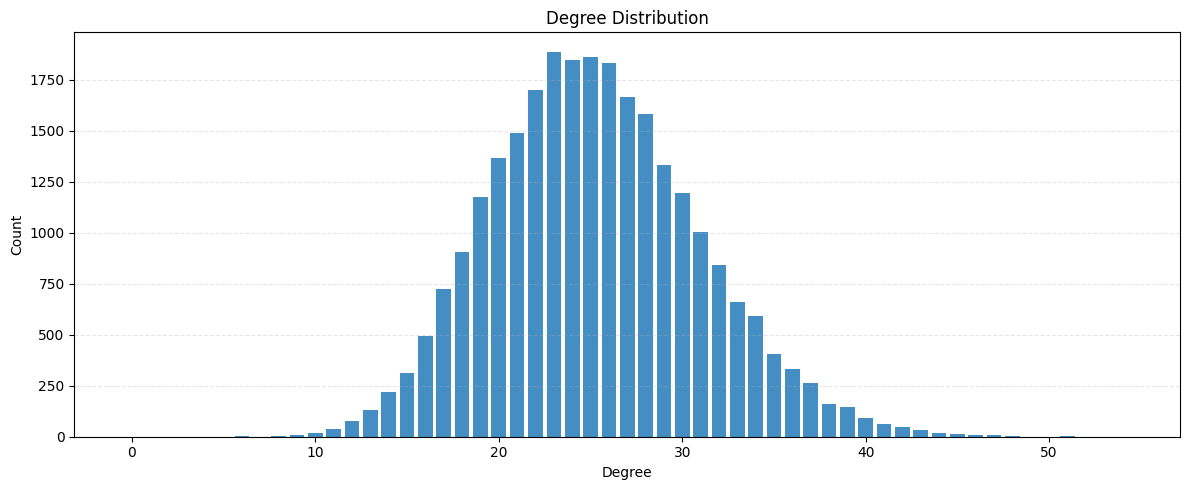

Clique size distribution (raw counts):
  Size 2: 298121 clique(s)
  Size 3: 2640 clique(s)
  Size 4: 2 clique(s)
  Size 5: 3055 clique(s)
Clique summary: total maximal cliques=303818, dominant size=2
Clique sizes present: 2, 3, 4, 5


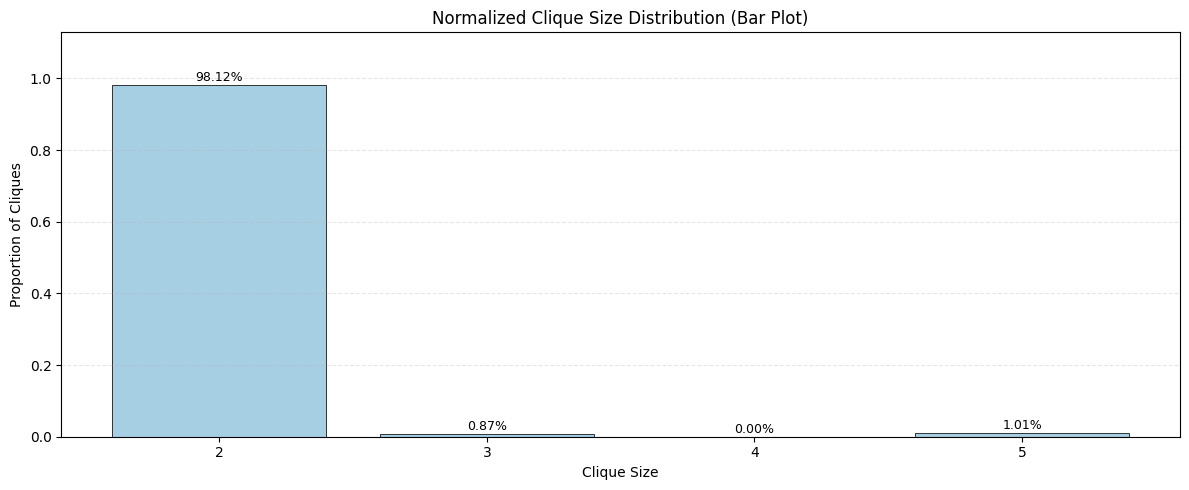

Simulation 5 valid: True
Batch summary:  rewires=3056,  attempts=268709,  termination=max_consecutive_failures
Simulation 5 complete - memory cleared.



In [7]:
def run_multiple_simulations(
    num_simulations,
    max_nodes,
    clique_size,
    visualise=False,
    print_summary=True,
):
    """
    Run several independent simulations, clearing memory between each run.

    @param num_simulations: Number of simulations to execute.
    @type  num_simulations: int
    @param max_nodes: Upper bound for the randomly chosen node count.
    @type  max_nodes: int
    @param clique_size: Target clique size passed to each simulation.
    @type  clique_size: int
    @param visualise: If True, print stats and plot distributions per run.
    @type  visualise: bool
    @param print_summary: Print compact stats for each run when True.
    @type  print_summary: bool
    """
    for i in range(num_simulations):
        model_valid = None
        run_stats = None
        print(f"Running simulation {i + 1}/{num_simulations}")
        try:
            node_count = rng.randint(20000, max_nodes)
            kmean = rng.randint(5, 50)
            print(
                f"Simulation parameters: nodes={node_count}, kmean={kmean}, clique_size={clique_size}"
            )
            model_valid, run_stats = run_single_network_simulation(
                node_count,
                kmean,
                clique_size,
                visualise=visualise,
                return_network=False,
                cleanup_after_run=False,
                print_summary=print_summary,
            )
            print(f"Simulation {i + 1} valid: {model_valid}")
            if run_stats is not None:
                print(
                    "Batch summary:",
                    f" rewires={run_stats['successful_rewirings']},",
                    f" attempts={run_stats['total_attempts']},",
                    f" termination={run_stats['termination_reason']}",
                )
        except ValueError:
            print("Simulation failed with current values, retrying")
            node_count = rng.randint(20000, max_nodes)
            kmean = rng.randint(5, 50)
            print(
                f"Retry parameters: nodes={node_count}, kmean={kmean}, clique_size={clique_size}"
            )
            model_valid, run_stats = run_single_network_simulation(
                node_count,
                kmean,
                clique_size,
                visualise=visualise,
                return_network=False,
                cleanup_after_run=False,
                print_summary=print_summary,
            )
            print(f"Simulation {i + 1} valid: {model_valid}")
            if run_stats is not None:
                print(
                    "Batch summary:",
                    f" rewires={run_stats['successful_rewirings']},",
                    f" attempts={run_stats['total_attempts']},",
                    f" termination={run_stats['termination_reason']}",
                )
        finally:
            model_valid = None
            run_stats = None
            _cleanup_simulation_state()
            print(f"Simulation {i + 1} complete - memory cleared.\n")


run_multiple_simulations(5, 30000, 5, visualise=True)

### Step 4.1.1 Conculsion
With this number of expanded number of nodes, we again see that the rewiring was able to make some changes in the clique counts, but not significantly as expected if we want to retain the degrees distribution. Due to the random formation of the network, we see that the occurance of a certain size of clique close to the desired target is not certainty. In some instances, it could be that some cliques of a particular value close to the target are never formed in a sigle network. 

### Step 4.2 Run Multiple simulations within a 20-40k Node range
**Note:** This may take some time (depending on the machine used) to complete.

Running simulation 1/5
Simulation parameters: nodes=23442, kmean=34, clique_size=5
ER network created
Total nodes: 23442
Total edges: 398513
Average degree: 33.99991468304752


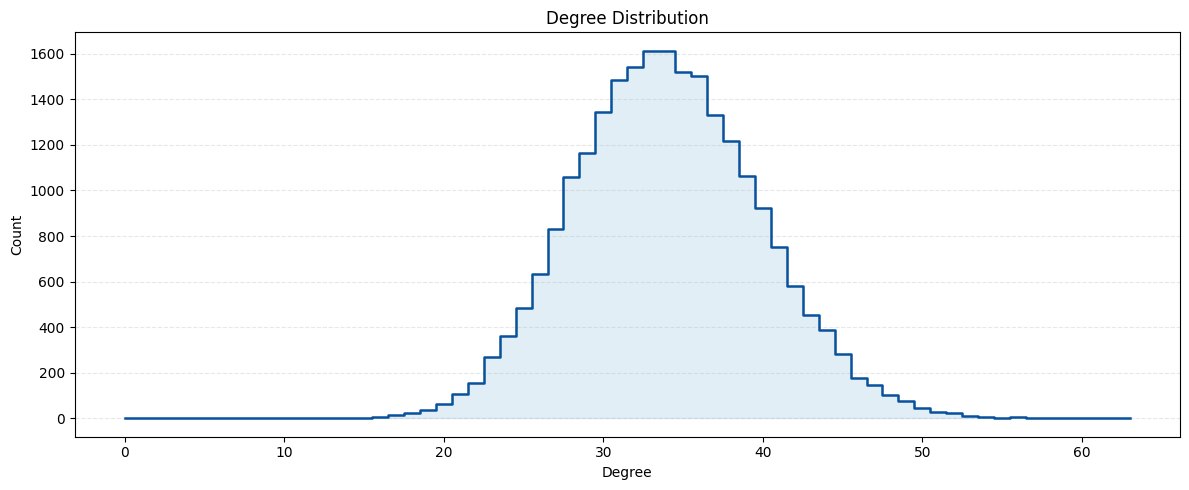

Clique size distribution (raw counts):
  Size 2: 379177 clique(s)
  Size 3: 6609 clique(s)
Clique summary: total maximal cliques=385786, dominant size=2
Clique sizes present: 2, 3


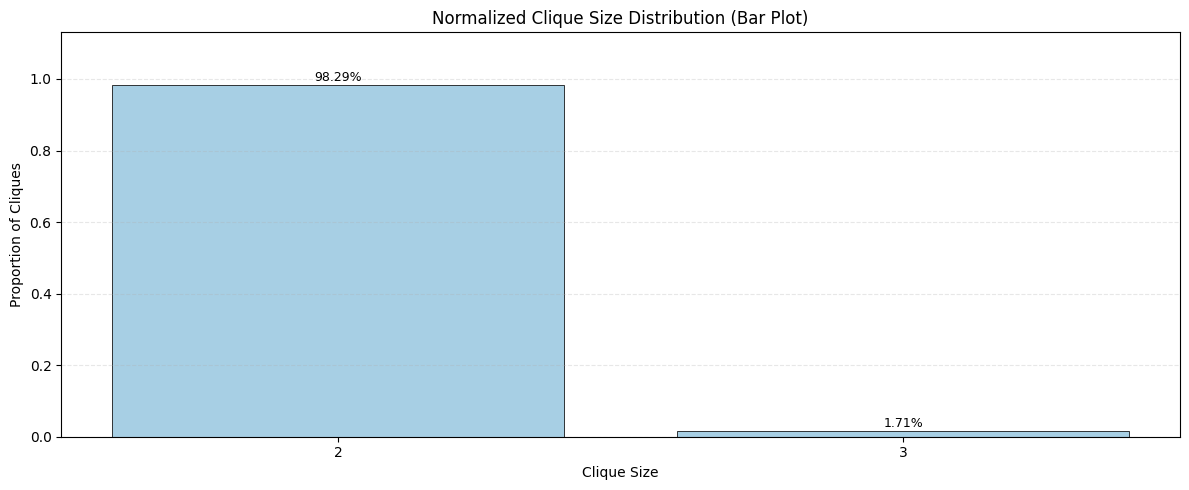

Rewiring stats:
  allowed clique sizes : [5, 4, 6, 3, 7]
  attempts            : 238414
  successful rewires  : 3991
  cache hits          : 0
  already-clique skips: 0
  tolerance rejections: 234423
  avg degree          : 33.9999 -> 37.3999
  stop reason         : max_consecutive_failures
ER network rewired (valid)
Total nodes: 23442
Total edges: 438364
Average degree: 37.39988055626653


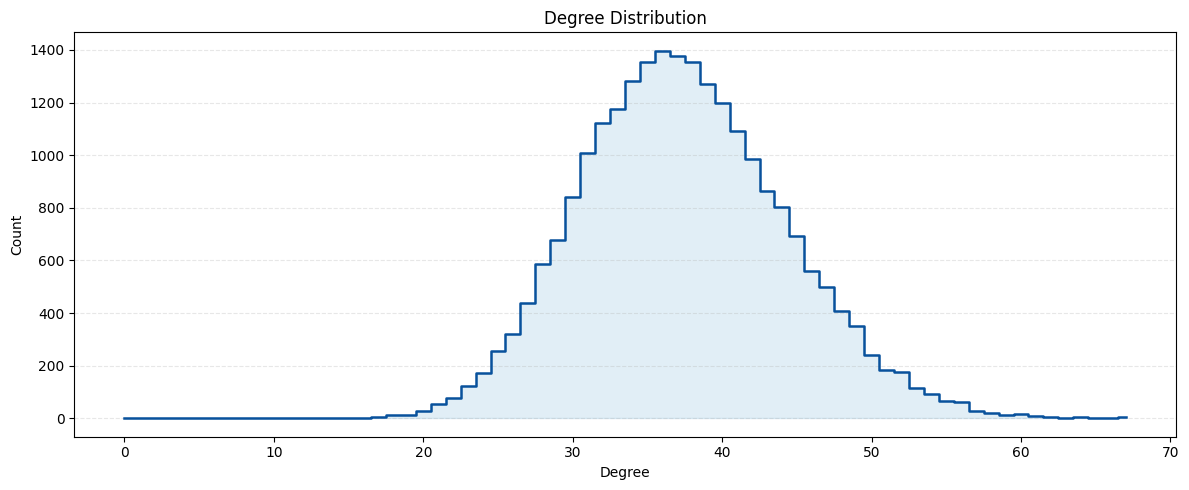

Clique size distribution (raw counts):
  Size 2: 375376 clique(s)
  Size 3: 8681 clique(s)
  Size 4: 5 clique(s)
  Size 5: 3990 clique(s)
Clique summary: total maximal cliques=388052, dominant size=2
Clique sizes present: 2, 3, 4, 5


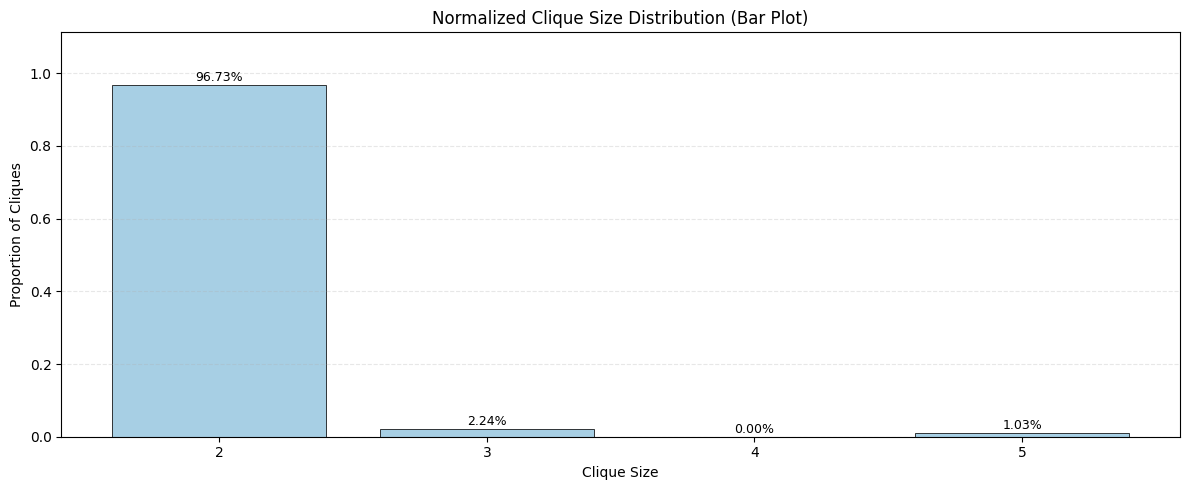

Simulation 1 valid: True
Batch summary:  rewires=3991,  attempts=238414,  termination=max_consecutive_failures
Simulation 1 complete - memory cleared.

Running simulation 2/5
Simulation parameters: nodes=26556, kmean=37, clique_size=5
ER network created
Total nodes: 26556
Total edges: 490990
Average degree: 36.97770748606718


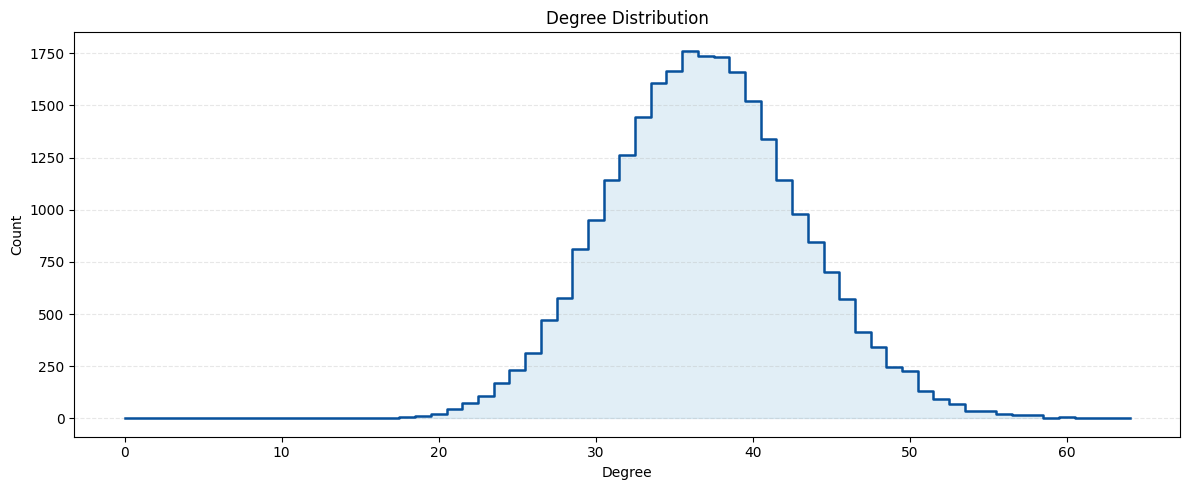

Clique size distribution (raw counts):
  Size 2: 466594 clique(s)
  Size 3: 8321 clique(s)
  Size 4: 1 clique(s)
Clique summary: total maximal cliques=474916, dominant size=2
Clique sizes present: 2, 3, 4


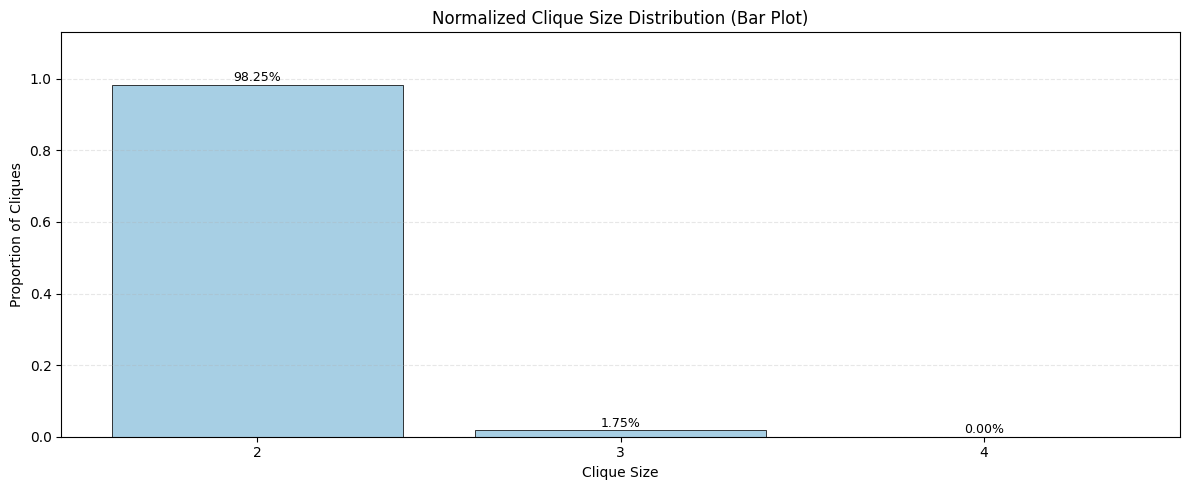

Rewiring stats:
  allowed clique sizes : [5, 4, 6, 3, 7]
  attempts            : 270478
  successful rewires  : 4917
  cache hits          : 0
  already-clique skips: 0
  tolerance rejections: 265561
  avg degree          : 36.9777 -> 40.6754
  stop reason         : max_consecutive_failures
ER network rewired (valid)
Total nodes: 26556
Total edges: 540088
Average degree: 40.67540292212683


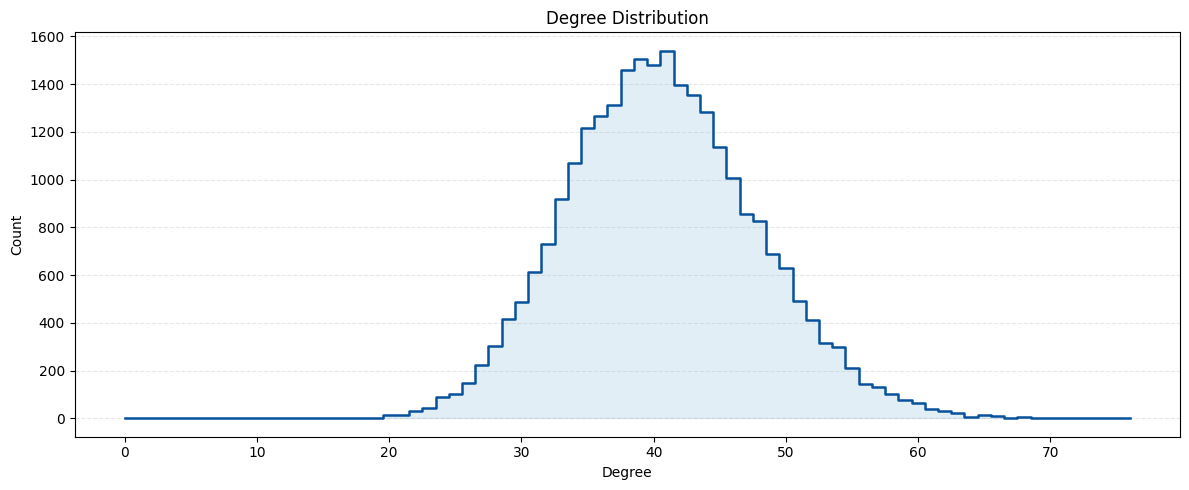

Clique size distribution (raw counts):
  Size 2: 461678 clique(s)
  Size 3: 11012 clique(s)
  Size 4: 6 clique(s)
  Size 5: 4916 clique(s)
Clique summary: total maximal cliques=477612, dominant size=2
Clique sizes present: 2, 3, 4, 5


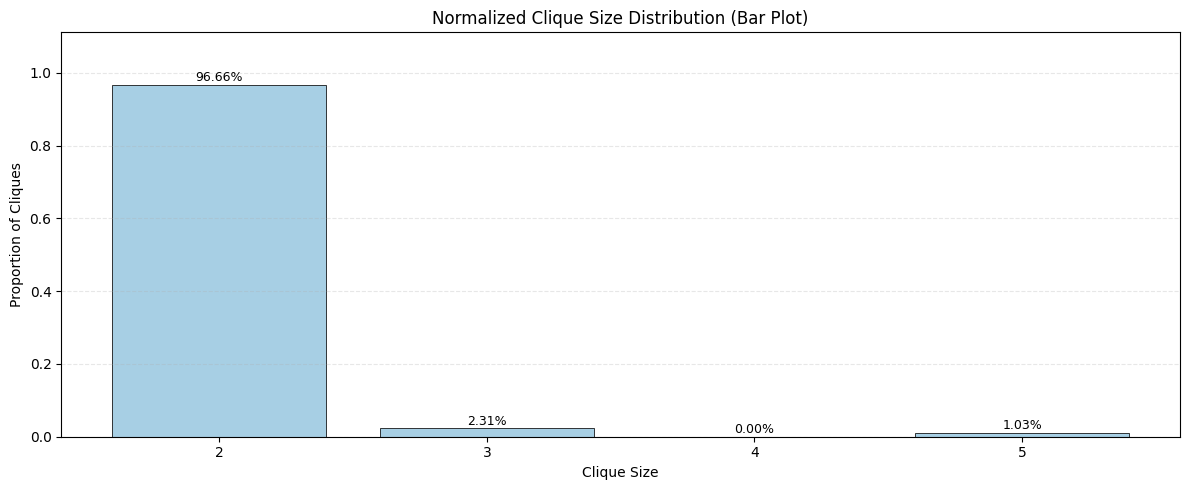

Simulation 2 valid: True
Batch summary:  rewires=4917,  attempts=270478,  termination=max_consecutive_failures
Simulation 2 complete - memory cleared.

Running simulation 3/5
Simulation parameters: nodes=30305, kmean=38, clique_size=5
ER network created
Total nodes: 30305
Total edges: 575572
Average degree: 37.98528295660782


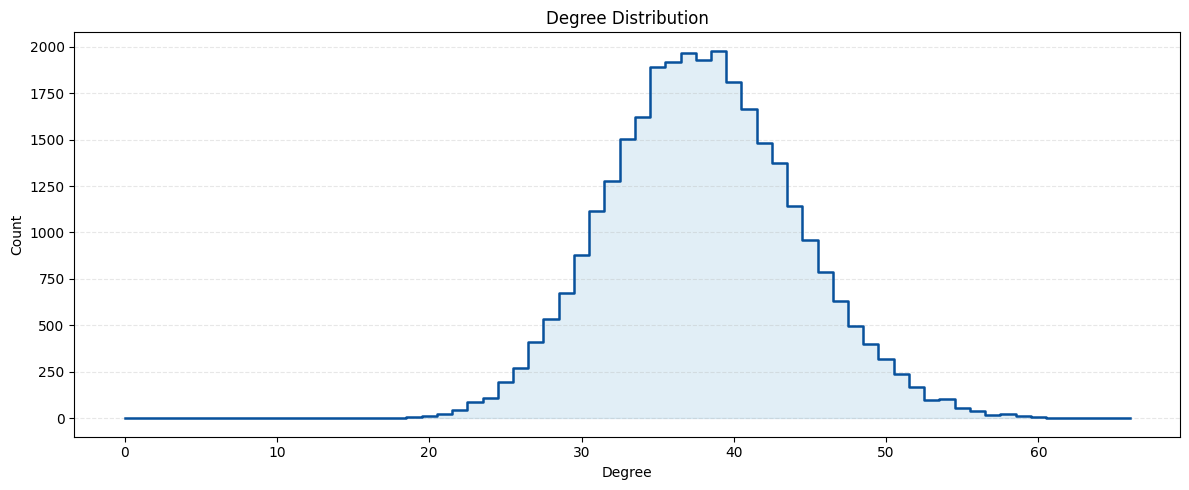

Clique size distribution (raw counts):
  Size 2: 548938 clique(s)
  Size 3: 9070 clique(s)
Clique summary: total maximal cliques=558008, dominant size=2
Clique sizes present: 2, 3


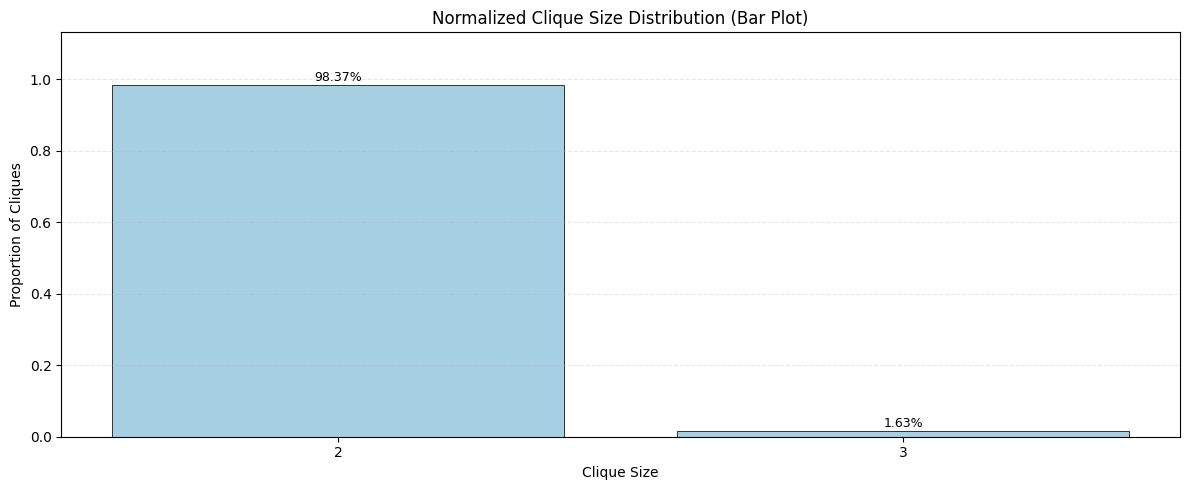

Rewiring stats:
  allowed clique sizes : [5, 4, 6, 3, 7]
  attempts            : 309908
  successful rewires  : 5765
  cache hits          : 0
  already-clique skips: 0
  tolerance rejections: 304143
  avg degree          : 37.9853 -> 41.7838
  stop reason         : max_consecutive_failures
ER network rewired (valid)
Total nodes: 30305
Total edges: 633129
Average degree: 41.783798053126546


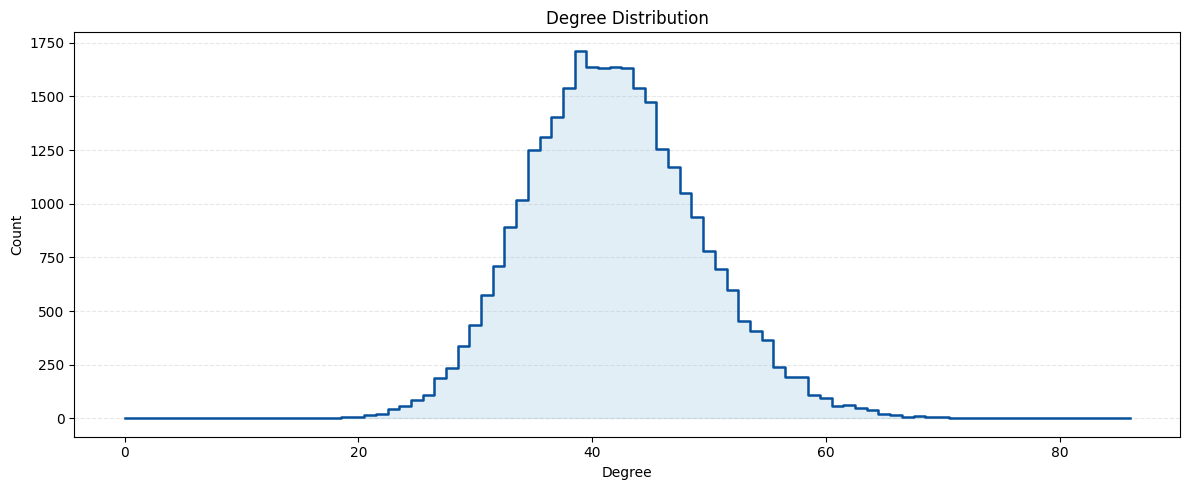

Clique size distribution (raw counts):
  Size 2: 543216 clique(s)
  Size 3: 12171 clique(s)
  Size 4: 4 clique(s)
  Size 5: 5764 clique(s)
Clique summary: total maximal cliques=561155, dominant size=2
Clique sizes present: 2, 3, 4, 5


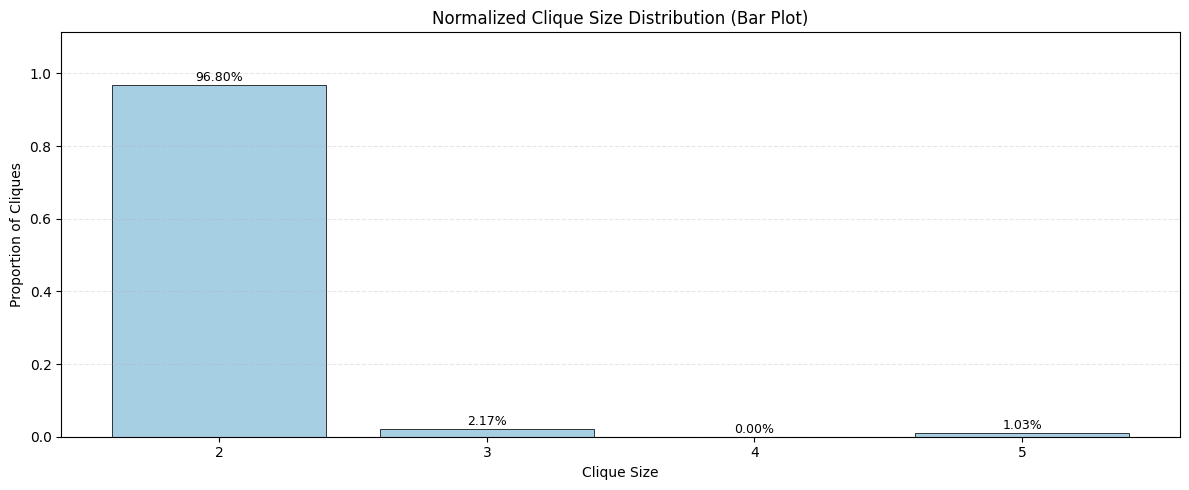

Simulation 3 valid: True
Batch summary:  rewires=5765,  attempts=309908,  termination=max_consecutive_failures
Simulation 3 complete - memory cleared.

Running simulation 4/5
Simulation parameters: nodes=25582, kmean=36, clique_size=5
ER network created
Total nodes: 25582
Total edges: 459409
Average degree: 35.916581971698854


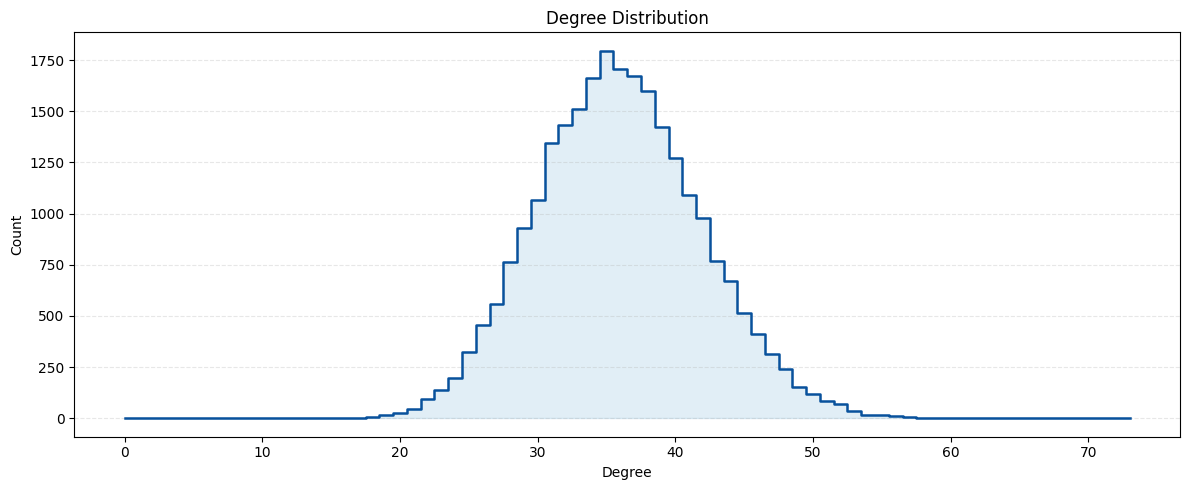

Clique size distribution (raw counts):
  Size 2: 437191 clique(s)
  Size 3: 7597 clique(s)
Clique summary: total maximal cliques=444788, dominant size=2
Clique sizes present: 2, 3


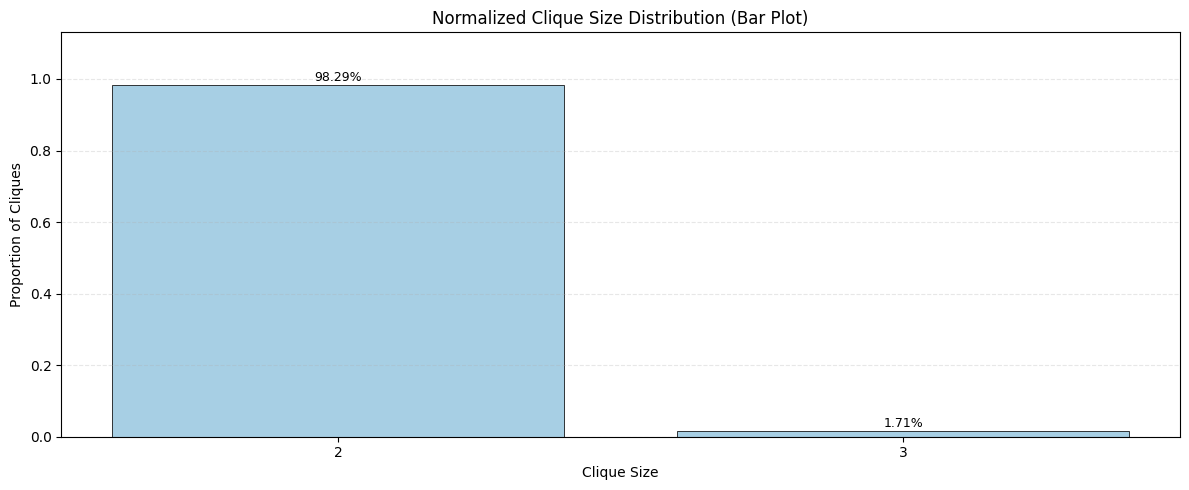

Rewiring stats:
  allowed clique sizes : [5, 4, 6, 3, 7]
  attempts            : 260425
  successful rewires  : 4602
  cache hits          : 0
  already-clique skips: 0
  tolerance rejections: 255823
  avg degree          : 35.9166 -> 39.5082
  stop reason         : max_consecutive_failures
ER network rewired (valid)
Total nodes: 25582
Total edges: 505349
Average degree: 39.508169806895474


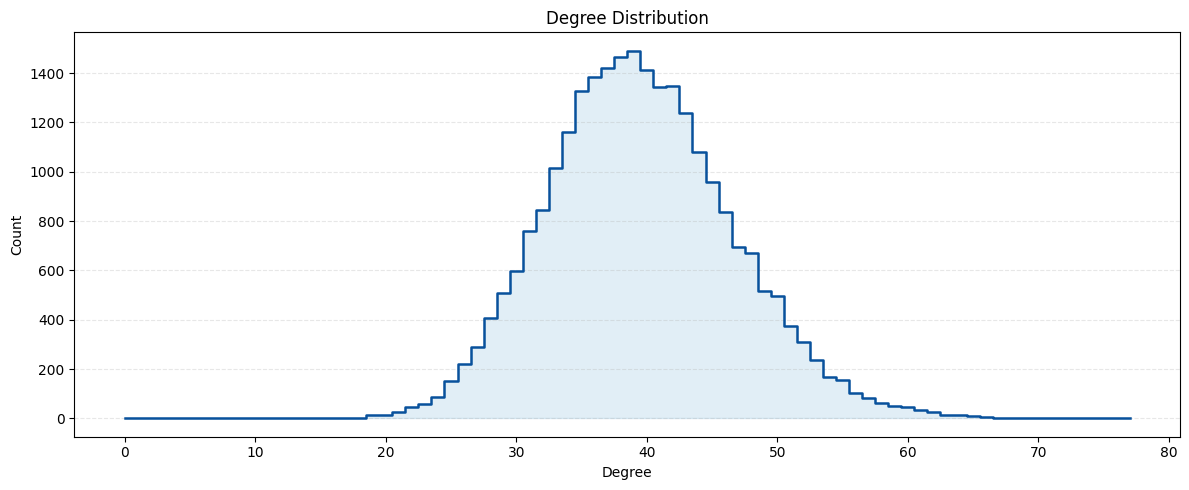

Clique size distribution (raw counts):
  Size 2: 432449 clique(s)
  Size 3: 10185 clique(s)
  Size 4: 3 clique(s)
  Size 5: 4601 clique(s)
Clique summary: total maximal cliques=447238, dominant size=2
Clique sizes present: 2, 3, 4, 5


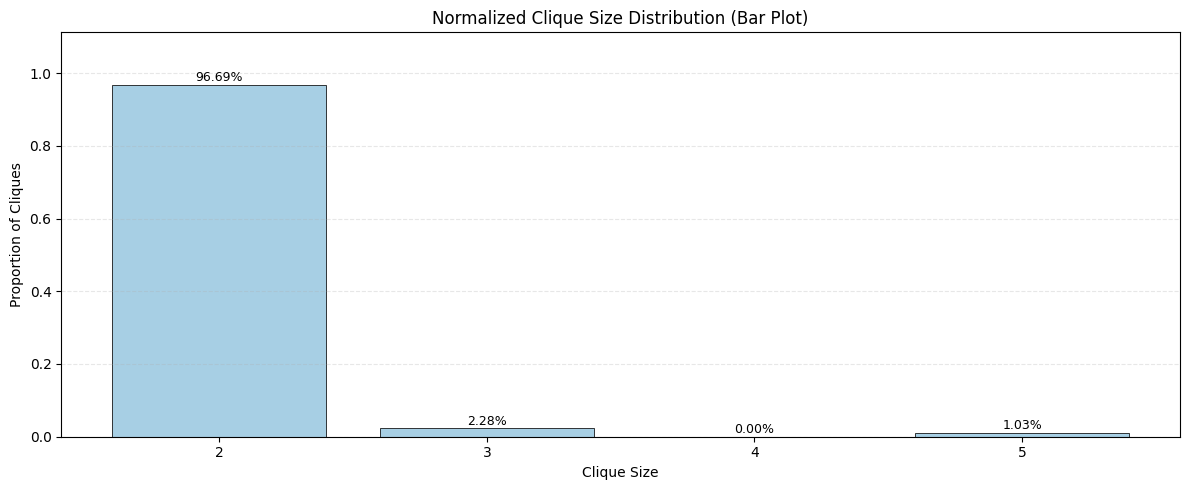

Simulation 4 valid: True
Batch summary:  rewires=4602,  attempts=260425,  termination=max_consecutive_failures
Simulation 4 complete - memory cleared.

Running simulation 5/5
Simulation parameters: nodes=33985, kmean=39, clique_size=5
ER network created
Total nodes: 33985
Total edges: 662877
Average degree: 39.00997498896572


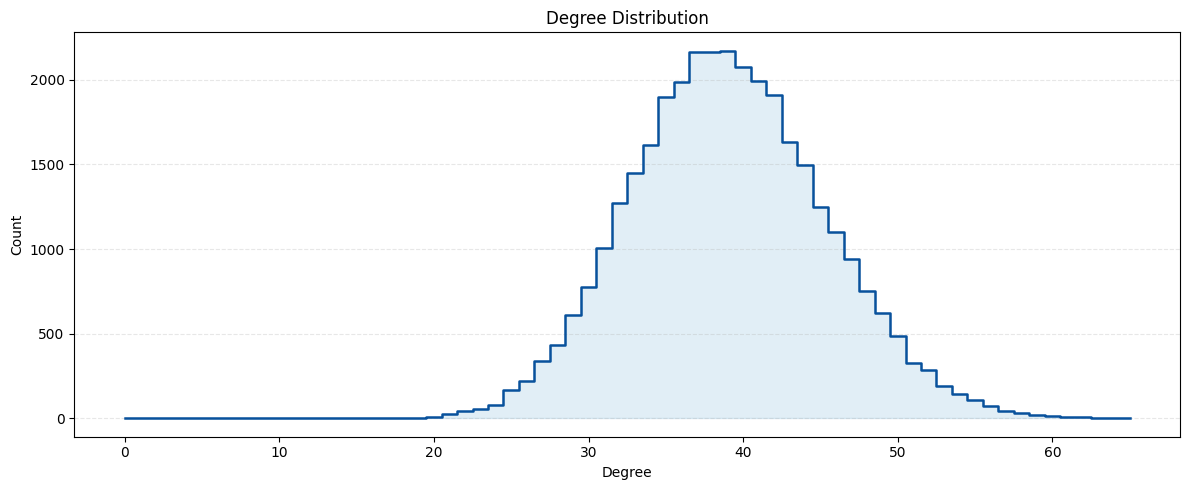

Clique size distribution (raw counts):
  Size 2: 633707 clique(s)
  Size 3: 9943 clique(s)
Clique summary: total maximal cliques=643650, dominant size=2
Clique sizes present: 2, 3


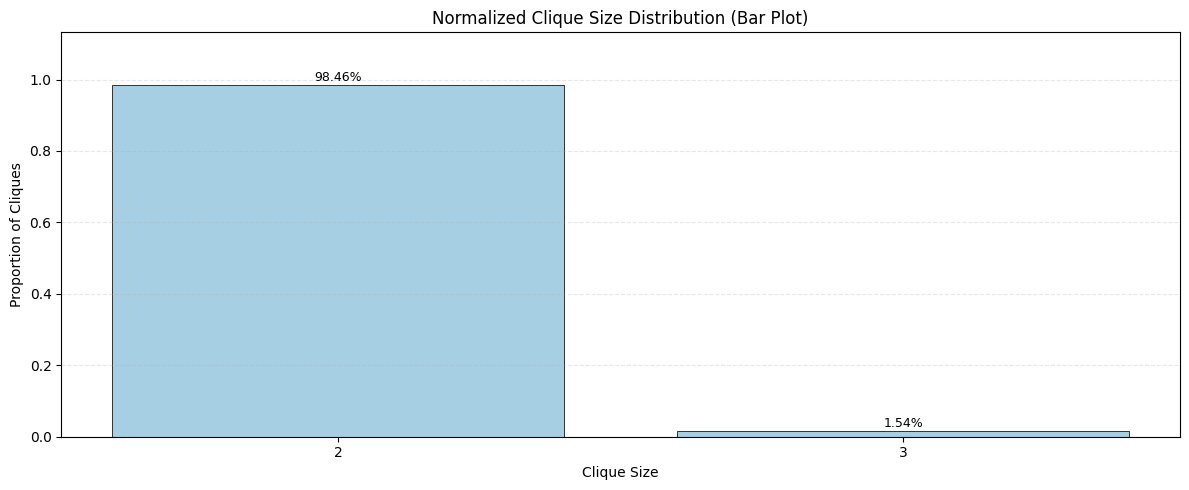

Rewiring stats:
  allowed clique sizes : [5, 4, 6, 3, 7]
  attempts            : 452549
  successful rewires  : 6638
  cache hits          : 0
  already-clique skips: 0
  tolerance rejections: 445911
  avg degree          : 39.0100 -> 42.9109
  stop reason         : max_consecutive_failures
ER network rewired (valid)
Total nodes: 33985
Total edges: 729164
Average degree: 42.910931293217594


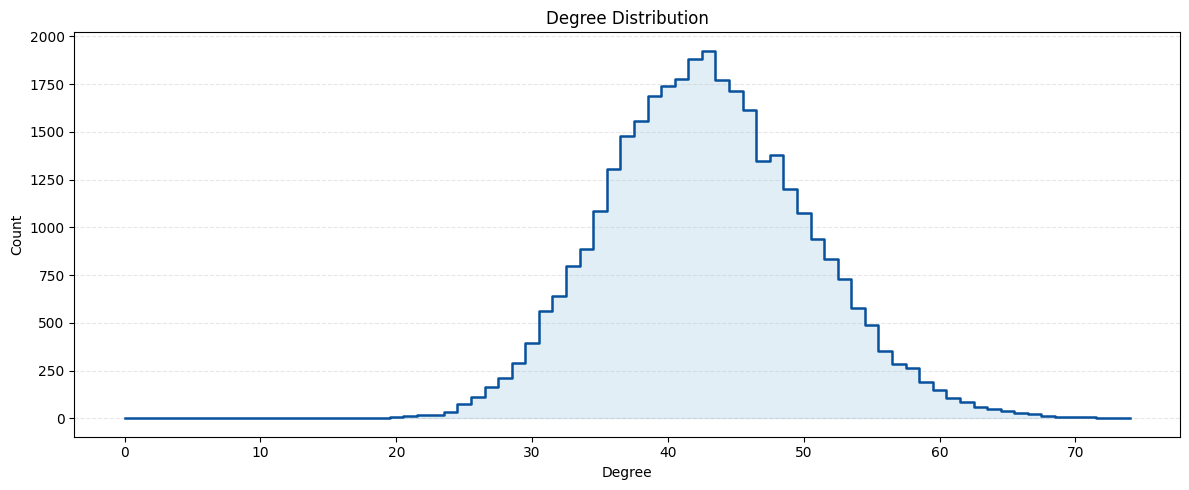

Clique size distribution (raw counts):
  Size 2: 627855 clique(s)
  Size 3: 13129 clique(s)
  Size 4: 6 clique(s)
  Size 5: 6636 clique(s)
Clique summary: total maximal cliques=647626, dominant size=2
Clique sizes present: 2, 3, 4, 5


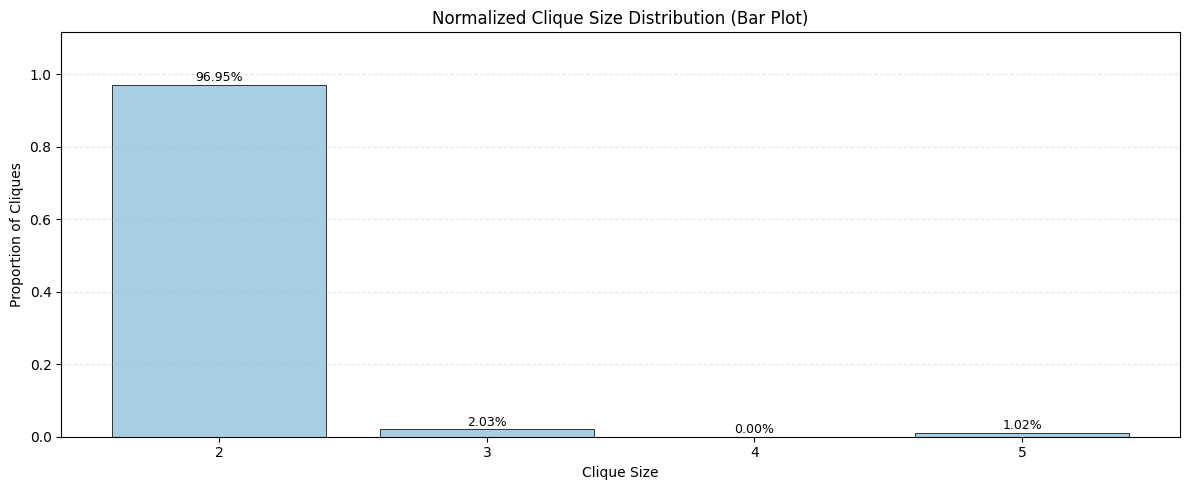

Simulation 5 valid: True
Batch summary:  rewires=6638,  attempts=452549,  termination=max_consecutive_failures
Simulation 5 complete - memory cleared.



In [8]:
run_multiple_simulations(5, 40000, 5, visualise=True)

### Step 4.2.1 Conclusion 
As with Step 4.1, a similar behaviour pattern can be seen within the rewiring process with regards to clique counts and the stochastic nature of the totals. There may, however, be a reduced possibility that clique values close to the target are not formed in a single network. This is primarily down to the increased number of nodes enabling a greater chance of a given clique being able to form. Possibility being the key word here, as there is no guarantee in this with the random nature of ER network formation.

# Step 5: Future Improvements
While it has been demonstrated that the rewiring process is capable to meet the requirements, going forward there would be some changes and improvements that could be made to optimise the system and to enahance the process of rewiring. These are: 
1. Incorporating parallel processing using multithreading in python. At the moment, the rewiring is a linear process. The code iterates through the nodes and attempts to rewire nodes into cliques, carries out validity of the rewiring, cancels the rewiring if neccisary, and then proceeds to the next node. With parallel processing, multiple nodes (depending on the resource availability) could go through this process at the same time - granted locking of nodes should also be included as to not cause inconsistencies in the network. The primary benefit of this could be to reduce the rewiring time required and allow for larger models of greater sizes to the ones used in this notebook to be processe in a optimal time. 
2. Enhanced Rewiring process. Currently, the process of rewiring covers the foundation with some levels of enhancments with regards to caching, and disallowing existing cliques within the target area to be rewired, and basic rule checking. As with the previous point, the process of node adjustments is sequential which means that rewiring works on a "first come, first serve" basis. By doing this, we could ignore a significant chunch of the network should the degree distribution be exeeded early on in the process - meaning most of the network is never considered. To combat this, it may be beneficial to implmement a random selection process so that the rewiring process is able to consider a wider scope of nodes across the network rather than just those that are first in line. This could allow for more rewiring to be done and more cliques to be formed within the target area.

# Step 6 Conclusions
By running observations at random node sizes within different boundaries, it was still possible to see the observations that were noted on the single simulation (see Output from simulation in step 4) across nearly all of the simulation runs. The run of the more expansive multiple simulation runs also demonstraded the reporducability of the rewiring process. In all experiments, it was observed that a small number of cliques were able to be formed close to or on the target area without massive deviations from the average degree distribution.

So it is possible to say that the rewiring process has met the critiera mentioned at the top of this document, though there is still room for improvement and as mentioned, future work may be able to improve the process.  